# Keşifsel Veri Analizi (EDA)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Kaynağı: /content/drive/MyDrive/Dataset/ECG_Dataset/ECG_Dataset
💾 EDA Çıktıları: /content/drive/MyDrive/ECG_Proje/EDA_Kesfi
✅ Tespit Edilen Sınıflar: ['Abnormal heartbeat', 'History of MI', 'Normal Person']
📊 Sınıf dağılım tablosu kaydedildi: /content/drive/MyDrive/ECG_Proje/EDA_Kesfi/1_sinif_dagilimi_tablosu.csv


/tmp/ipython-input-1668386705.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


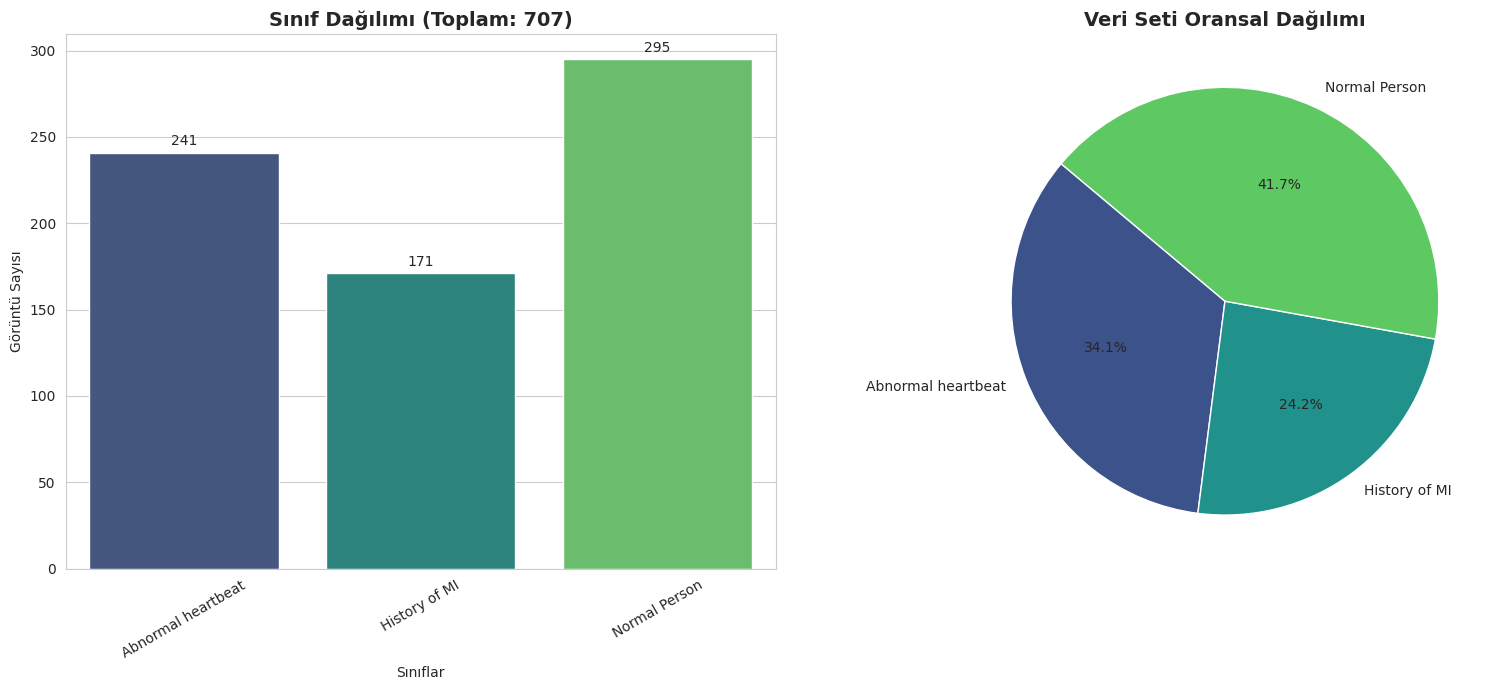


🖼️ Örnek ECG görüntüleri hazırlanıyor...


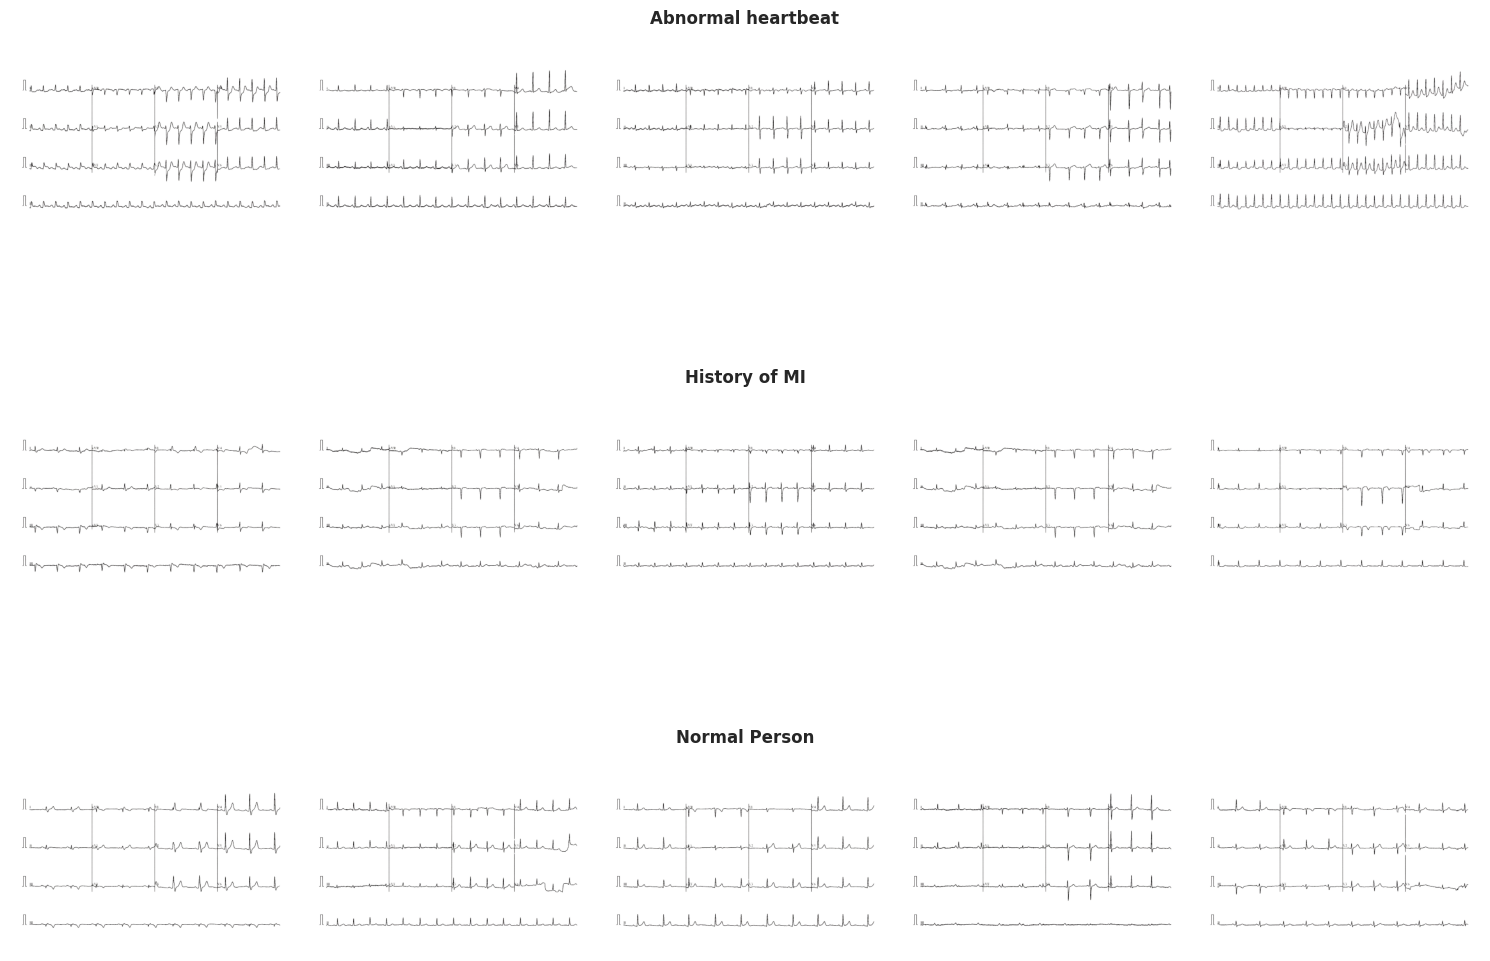


📏 ECG görüntüleri için boyut & parlaklık analizi...


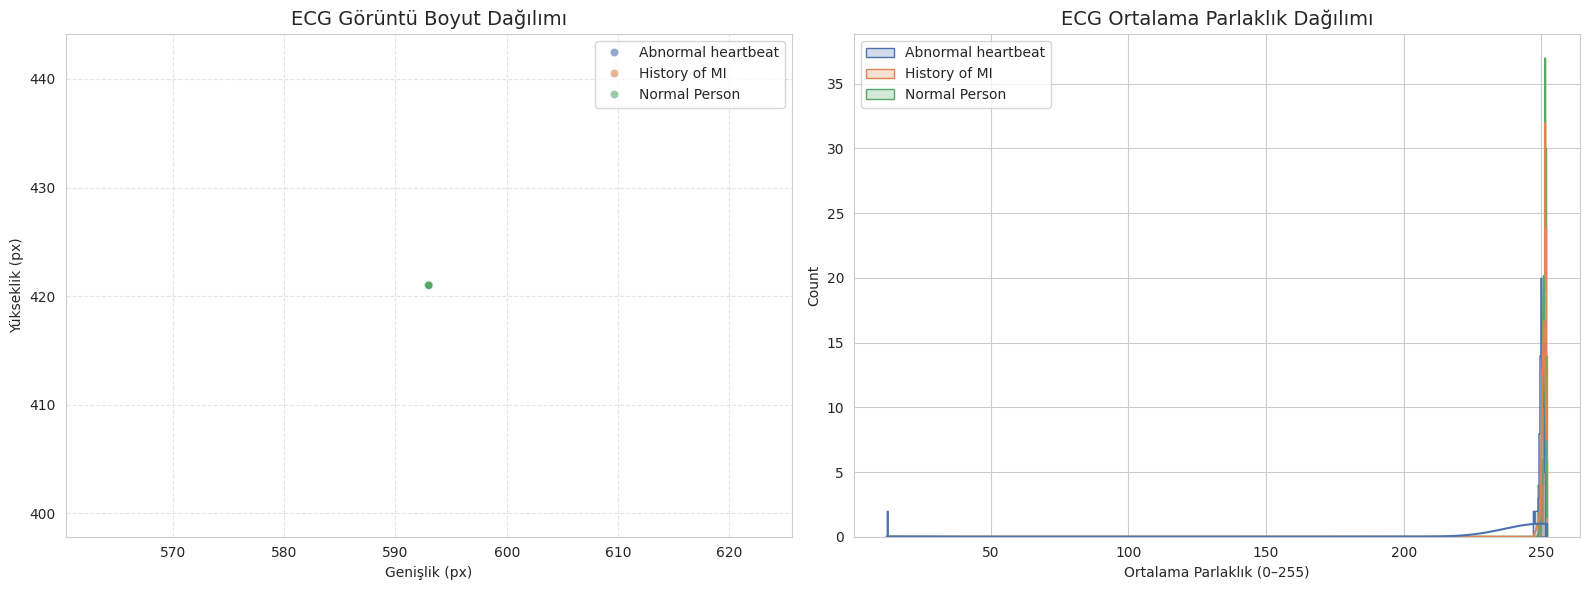


✅ ECG EDA KEŞFİ TAMAMLANDI
📂 Tüm çıktılar burada: /content/drive/MyDrive/ECG_Proje/EDA_Kesfi
📄 Üretilen dosyalar:
 - 1_sinif_dagilimi_tablosu.csv
 - 1_sinif_dagilimi_grafigi.png
 - 2_ornek_ecg_goruntuler.png
 - 3_boyut_ve_parlaklik_analizi.png


In [ ]:
# =========================================================
# ECG DATASET - EDA KEŞFİ
# =========================================================
# Bu script, ECG görüntü veri seti üzerinde Keşifsel Veri Analizi (EDA) yapmak için hazırlanmıştır.
# Amaç: sınıf dağılımı, örnek görüntüler, çözünürlük ve parlaklık analizlerini görselleştirmek.

import os                          # Dosya ve klasör işlemleri için
import random                      # Rastgele örnekleme yapmak için
import cv2                         # Görüntü okuma ve işleme (OpenCV)
import numpy as np                 # Sayısal işlemler için
import matplotlib.pyplot as plt    # Grafik çizimi için
import seaborn as sns              # İstatistiksel görselleştirme için
import pandas as pd                # Tablo (DataFrame) işlemleri için
from collections import Counter   # Sayma işlemleri (ileride gerekebilir)

# =========================================================
# 1. AYARLAR
# =========================================================
sns.set_style("whitegrid")         # Seaborn grafik stilini beyaz grid olarak ayarlar
plt.rcParams['figure.figsize'] = (12, 8)  # Varsayılan grafik boyutunu belirler

# =========================================================
# 2. YOLLAR VE AYARLAR
# =========================================================
# ECG görüntülerinin bulunduğu ana veri seti klasörü
DATASET_PATH = os.path.join("..", "dataset", "ECG_Dataset")

# EDA sonucunda üretilecek görsellerin ve tabloların kaydedileceği klasör
SAVE_DIR = os.path.join("..", "results", "EDA")
os.makedirs(SAVE_DIR, exist_ok=True)  # Klasör yoksa oluşturur

# Kullanıcıya hangi dizinlerin kullanıldığını bilgi olarak yazdırır
print(f"📂 Veri Kaynağı: {DATASET_PATH}")
print(f"💾 EDA Çıktıları: {SAVE_DIR}")

# =========================================================
# 3. SINIFLARI OKU
# =========================================================
class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
    and not d.startswith('.')
])

print(f"✅ Tespit Edilen Sınıflar: {class_names}")

# =========================================================
# 4. SINIF DAĞILIMI ANALİZİ
# =========================================================
class_counts = {}
total_images = 0

valid_ext = ('.png', '.jpg', '.jpeg')

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(valid_ext)]
    class_counts[cls] = len(imgs)
    total_images += len(imgs)

df_counts = pd.DataFrame(list(class_counts.items()),
                         columns=["Sinif", "Goruntu_Sayisi"])

df_counts["Oran_Yuzde"] = (df_counts["Goruntu_Sayisi"] / total_images) * 100

csv_path = os.path.join(SAVE_DIR, "1_sinif_dagilimi_tablosu.csv")
df_counts.to_csv(csv_path, index=False)

print(f"📊 Sınıf dağılım tablosu kaydedildi: {csv_path}")

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
ax = sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values()),
    palette="viridis"
)
plt.title(f"Sınıf Dağılımı (Toplam: {total_images})", fontsize=14, fontweight="bold")
plt.xlabel("Sınıflar")
plt.ylabel("Görüntü Sayısı")
plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points'
    )

plt.subplot(1, 2, 2)
plt.pie(
    class_counts.values(),
    labels=class_counts.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("viridis", len(class_names))
)
plt.title("Veri Seti Oransal Dağılımı", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "1_sinif_dagilimi_grafigi.png"),
            dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 5. ÖRNEK ECG GÖRÜNTÜLERİ (GRID)
# =========================================================
print("\n🖼️ Örnek ECG görüntüleri hazırlanıyor...")

plt.figure(figsize=(15, 4 * len(class_names)))

for i, cls in enumerate(class_names):
    cls_folder = os.path.join(DATASET_PATH, cls)
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(valid_ext)]

    sample_count = min(len(images), 5)
    samples = random.sample(images, sample_count)

    for j, img_name in enumerate(samples):
        img_path = os.path.join(cls_folder, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(len(class_names), 5, i * 5 + j + 1)
            plt.imshow(img)
            plt.axis("off")

            if j == 2:
                plt.title(cls, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "2_ornek_ecg_goruntuler.png"),
            dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 6. YAPISAL ANALİZ (BOYUT & PARLAKLIK)
# =========================================================
print("\n📏 ECG görüntüleri için boyut & parlaklık analizi...")

widths, heights, brightness_vals, labels_stats = [], [], [], []

for cls in class_names:
    cls_folder = os.path.join(DATASET_PATH, cls)
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(valid_ext)]

    sample_size = min(len(images), 100)
    samples = random.sample(images, sample_size)

    for img_name in samples:
        img_path = os.path.join(cls_folder, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            h, w, _ = img.shape
            heights.append(h)
            widths.append(w)
            brightness_vals.append(np.mean(img))
            labels_stats.append(cls)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=widths,
    y=heights,
    hue=labels_stats,
    alpha=0.6,
    palette="deep"
)
plt.title("ECG Görüntü Boyut Dağılımı", fontsize=14)
plt.xlabel("Genişlik (px)")
plt.ylabel("Yükseklik (px)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(1, 2, 2)
sns.histplot(
    x=brightness_vals,
    hue=labels_stats,
    kde=True,
    element="step",
    palette="deep"
)
plt.title("ECG Ortalama Parlaklık Dağılımı", fontsize=14)
plt.xlabel("Ortalama Parlaklık (0–255)")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "3_boyut_ve_parlaklik_analizi.png"),
            dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 7. ÖZET
# =========================================================
print("\n✅ ECG EDA KEŞFİ TAMAMLANDI")
print(f"📂 Tüm çıktılar burada: {SAVE_DIR}")
print("📄 Üretilen dosyalar:")
print(" - 1_sinif_dagilimi_tablosu.csv")
print(" - 1_sinif_dagilimi_grafigi.png")
print(" - 2_ornek_ecg_goruntuler.png")
print(" - 3_boyut_ve_parlaklik_analizi.png")

# Dublicate Removel (Veri Temizleme)

In [ ]:
# ======================================================
# ECG DATASET DUPLICATE REMOVAL + SANITY CHECK (ONE CELL)
# ======================================================
# Bu script ECG görüntü veri setinde duplicate (tekrar eden) görselleri
# algılamak, ayırmak ve temiz bir veri seti oluşturmak için kullanılır.
# Aynı zamanda eğitim öncesi sanity check (son kontrol) yapılır.

# ---------- LIBRARIES ----------
import os                       # Dosya ve klasör işlemleri
import shutil                   # Dosya kopyalama işlemleri
import numpy as np              # Sayısal işlemler
from PIL import Image           # Görüntü açma ve dönüştürme
import imagehash                # Perceptual hash (pHash) hesaplamak için
from skimage.metrics import structural_similarity as ssim  # SSIM benzerlik metriği

# ---------- FLAGS ----------
RUN_SANITY_CHECK = True         # True ise sadece raporlama yapılır, silme işlemi yoktur

# ---------- PATHS ----------
DATASET_DIR = os.path.join("..", "dataset", "ECG_Dataset")                 # Orijinal veri seti
CLEAN_DIR   = os.path.join("..", "dataset", "ECG_Dataset_Clean")           # Temizlenmiş veri seti
DUP_DIR     = os.path.join("..", "results", "Data_Cleaning_EDA", "DUPLICATES")  # Duplicate görüntüler

# Gerekli klasörler yoksa oluşturulur
os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(DUP_DIR, exist_ok=True)

# ---------- SETTINGS ----------
SSIM_THRESHOLD = 0.98         # SSIM benzerliği bu değerin üzerindeyse duplicate kabul edilir

hash_dict = {}                # Görüntü hash'lerini tutar → hash : (class_name, img_path)
total_images = 0              # Toplam taranan görüntü sayısı
duplicate_count = 0           # Tespit edilen duplicate görüntü sayısı

print("\n========== DUPLICATE ANALYSIS STARTED ==========\n")

# ---------- MAIN LOOP ----------
# Veri setindeki her sınıf klasörü için döngü
for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)

    # Klasör değilse atla
    if not os.path.isdir(class_path):
        continue

    # Temiz ve duplicate klasörlerini sınıf bazında oluşturur
    clean_class_dir = os.path.join(CLEAN_DIR, class_name)
    dup_class_dir   = os.path.join(DUP_DIR, class_name)

    os.makedirs(clean_class_dir, exist_ok=True)
    os.makedirs(dup_class_dir, exist_ok=True)

    # Sınıf içindeki tüm görüntüler için döngü
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        total_images += 1      # Toplam görüntü sayısını artır

        try:
            # Görüntüyü gri seviyeye çevirir ve sabit boyuta getirir
            img = Image.open(img_path).convert("L").resize((256, 256))

            # Görüntünün perceptual hash değerini hesaplar
            img_hash = imagehash.phash(img)

            # Eğer bu hash daha önce görülmediyse
            if img_hash not in hash_dict:
                hash_dict[img_hash] = (class_name, img_path)
                shutil.copy(img_path, os.path.join(clean_class_dir, img_name))

            else:
                # Aynı hash'e sahip eski görüntüyü al
                old_class, old_path = hash_dict[img_hash]
                old_img = Image.open(old_path).convert("L").resize((256, 256))

                # SSIM ile gerçek görsel benzerliğini ölç
                sim = ssim(np.array(img), np.array(old_img))

                # Eğer SSIM eşik değerinin üzerindeyse duplicate kabul edilir
                if sim >= SSIM_THRESHOLD:
                    duplicate_count += 1
                    shutil.copy(img_path, os.path.join(dup_class_dir, img_name))

                    # Duplicate bilgilerini detaylı şekilde ekrana yazdırır
                    print("DUPLICATE FOUND 🔁")
                    print(f"  → Class 1 : {old_class}")
                    print(f"  → Image 1 : {old_path}")
                    print(f"  → Class 2 : {class_name}")
                    print(f"  → Image 2 : {img_path}")
                    print(f"  → SSIM    : {sim:.4f}")
                    print("-" * 60)

                else:
                    # Hash aynı olsa bile görsel farklıysa temiz klasöre ekler
                    shutil.copy(img_path, os.path.join(clean_class_dir, img_name))

        # Görüntü okuma veya işleme hatası olursa yakalar
        except Exception as e:
            print(f"❌ ERROR: {img_path} -> {e}")

print("\n========== DUPLICATE ANALYSIS FINISHED ==========")
print(f"Toplam görüntü sayısı        : {total_images}")
print(f"Benzersiz görüntü (hash)    : {len(hash_dict)}")
print(f"Ayıklanan duplicate sayısı  : {duplicate_count}")

# ======================================================
# FINAL SANITY CHECK (OPTIONAL)
# ======================================================
# Temiz veri setinde sınıf başına görüntü sayısını kontrol eder
if RUN_SANITY_CHECK:
    print("\n========== FINAL SANITY CHECK ==========\n")

    for class_name in os.listdir(CLEAN_DIR):
        class_path = os.path.join(CLEAN_DIR, class_name)

        # Klasör değilse atla
        if not os.path.isdir(class_path):
            continue

        imgs = os.listdir(class_path)
        print(f"{class_name:<20} : {len(imgs)} görüntü")

    print("\nSanity check tamamlandı. Eğitim için hazır ✔")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

========== DUPLICATE ANALYSIS STARTED ==========

DUPLICATE FOUND 🔁
  → Class 1 : History of MI
  → Image 1 : /content/drive/MyDrive/ECG/ECG_Dataset/History of MI/PMI_(94).png
  → Class 2 : History of MI
  → Image 2 : /content/drive/MyDrive/ECG/ECG_Dataset/History of MI/PMI_(93).png
  → SSIM    : 1.0000
------------------------------------------------------------
DUPLICATE FOUND 🔁
  → Class 1 : History of MI
  → Image 1 : /content/drive/MyDrive/ECG/ECG_Dataset/History of MI/PMI_(94).png
  → Class 2 : History of MI
  → Image 2 : /content/drive/MyDrive/ECG/ECG_Dataset/History of MI/PMI_(7).png
  → SSIM    : 1.0000
------------------------------------------------------------
DUPLICATE FOUND 🔁
  → Class 1 : History of MI
  → Image 1 : /content/drive/MyDrive/ECG/ECG_Dataset/History of MI/PMI_(9).png
  → Class 2 : History of MI
  → Image 2 : /content/drive/MyDrive

# Dublicate Edilmiş Dataset Için Keşifsel Veri Analizi (EDA)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Kaynağı: /content/drive/MyDrive/ECG/ECG_Dataset_Clean
💾 EDA Çıktıları: /content/drive/MyDrive/ECG_Proje/Dublicates_EDA_Kesfi
✅ Tespit Edilen Sınıflar: ['Abnormal heartbeat', 'History of MI', 'Normal Person']
📊 Sınıf dağılım tablosu kaydedildi: /content/drive/MyDrive/ECG_Proje/Dublicates_EDA_Kesfi/1_sinif_dagilimi_tablosu.csv


/tmp/ipython-input-1135078487.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


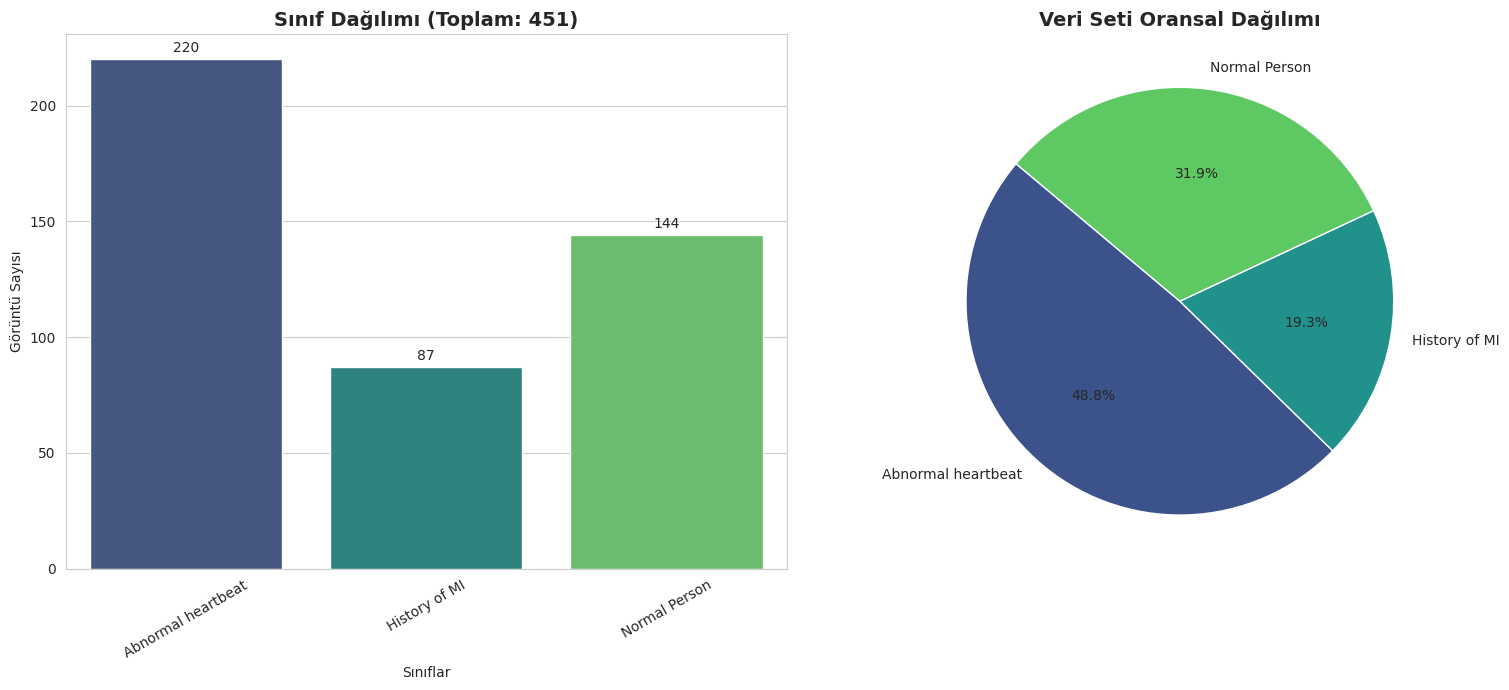


🖼️ Örnek ECG görüntüleri hazırlanıyor...


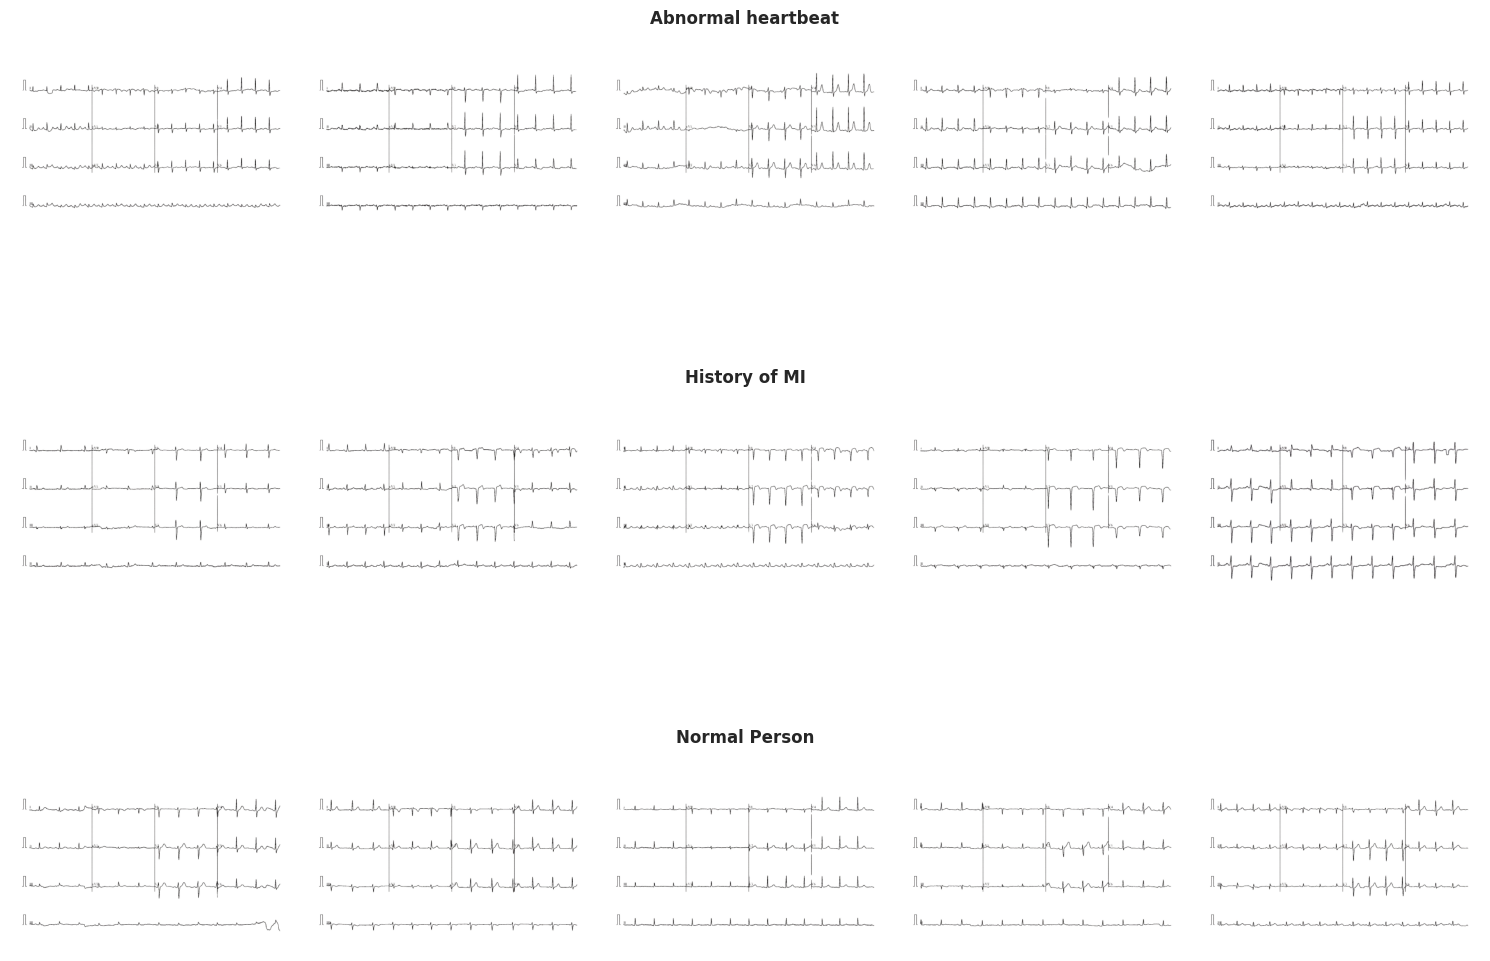


📏 ECG görüntüleri için boyut & parlaklık analizi...


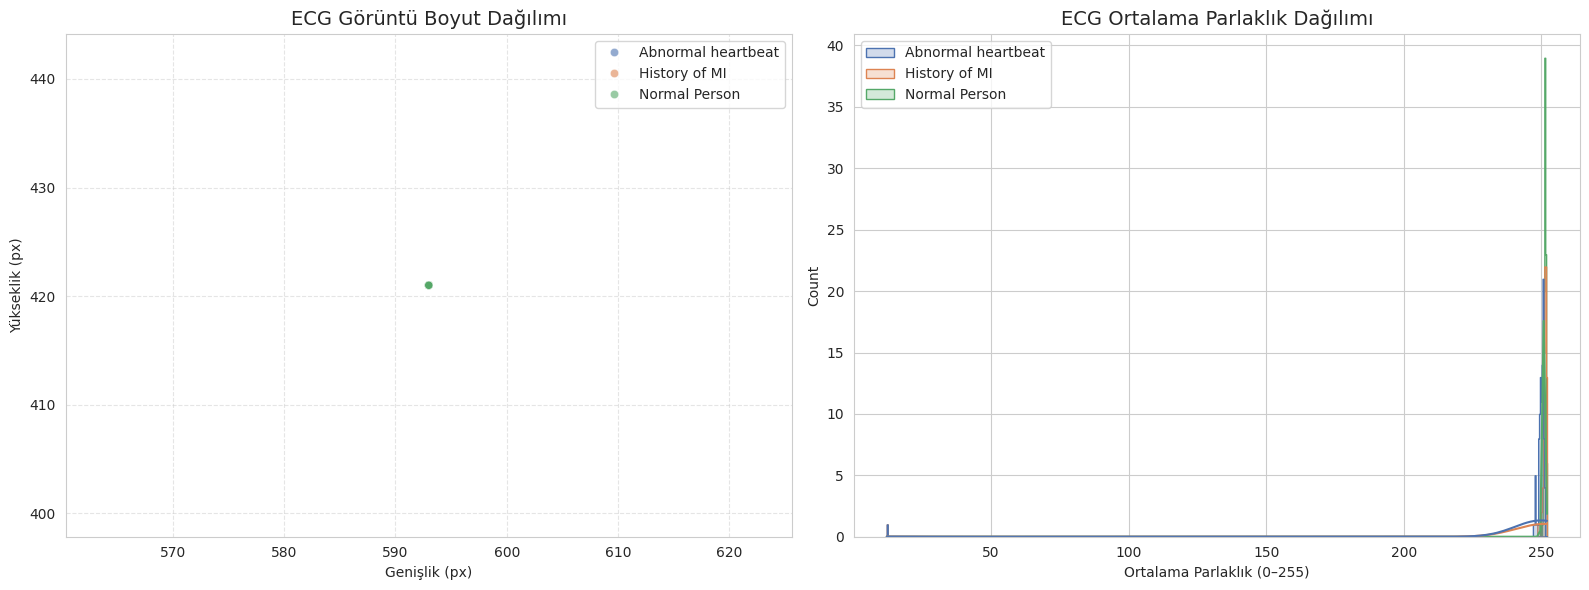


✅ ECG EDA KEŞFİ TAMAMLANDI
📂 Tüm çıktılar burada: /content/drive/MyDrive/ECG_Proje/Dublicates_EDA_Kesfi
📄 Üretilen dosyalar:
 - 1_sinif_dagilimi_tablosu.csv
 - 1_sinif_dagilimi_grafigi.png
 - 2_ornek_ecg_goruntuler.png
 - 3_boyut_ve_parlaklik_analizi.png


In [ ]:
# =========================================================
# ECG DATASET - EDA KEŞFİ
# =========================================================
# Bu script: temizlenmiş ECG veri seti üzerinde EDA (Exploratory Data Analysis) yapar.
# Üretilen çıktılar: sınıf dağılım CSV + bar/pie grafikleri, örnek görüntü grid'i, boyut ve parlaklık analiz grafikleri.

import os                           # Dosya/klasör işlemleri (listeleme, path birleştirme, klasör oluşturma vb.)
import random                       # Rastgele örnek görüntü seçimi için
import cv2                          # Görüntü okuma ve renk dönüşümü için (OpenCV)
import numpy as np                  # Sayısal işlemler (ör. ortalama parlaklık hesabı) için
import matplotlib.pyplot as plt     # Grafik çizimi ve figür yönetimi için
import seaborn as sns               # Daha estetik istatistiksel grafikler için
import pandas as pd                 # Tablo oluşturma ve CSV kaydetme için
from collections import Counter     # Sayma işlemleri için (bu scriptte import edilmiş ama kullanılmıyor)

sns.set_style("whitegrid")          # Seaborn grafik stilini "whitegrid" olarak ayarlar
plt.rcParams['figure.figsize'] = (12, 8)  # Matplotlib için varsayılan figür boyutunu belirler

# =========================================================
# 2. YOLLAR VE AYARLAR
# =========================================================
# 🔹 ECG veri seti (KAYNAK)
DATASET_PATH = os.path.join("..", "dataset", "ECG_Dataset_Clean")

# 🔹 EDA çıktıları (AYRI KLASÖR)
SAVE_DIR = os.path.join("..", "results", "Data_Cleaning_EDA")
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Kaynağı: {DATASET_PATH}")
print(f"💾 EDA Çıktıları: {SAVE_DIR}")

# =========================================================
# 3. SINIFLARI OKU
# =========================================================
# DATASET_PATH içindeki alt klasörleri sınıf olarak kabul eder; gizli klasörleri dışlar.
class_names = sorted([
    d for d in os.listdir(DATASET_PATH)                          # DATASET_PATH içindeki tüm öğeleri listeler
    if os.path.isdir(os.path.join(DATASET_PATH, d))              # Sadece klasör olanları alır (dosyaları alma)
    and not d.startswith('.')                                    # '.' ile başlayanları (gizli klasörleri) alma
])

print(f"✅ Tespit Edilen Sınıflar: {class_names}")  # Bulunan sınıf isimlerini yazdırır

# =========================================================
# 4. SINIF DAĞILIMI ANALİZİ
# =========================================================
class_counts = {}     # Her sınıf için görüntü sayısını tutacak sözlük
total_images = 0      # Toplam görüntü sayısını tutacak sayaç

valid_ext = ('.png', '.jpg', '.jpeg')  # Geçerli görüntü uzantıları

# Her sınıf klasörüne girip geçerli uzantılı görüntüleri sayar
for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)                              # İlgili sınıf klasörünün tam yolu
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(valid_ext)]  # Uzantıya göre görüntüleri filtreler
    class_counts[cls] = len(imgs)                                           # Sınıfın görüntü sayısını kaydeder
    total_images += len(imgs)                                               # Toplam görüntü sayısını artırır

# --- CSV Kaydet ---
# Sınıf dağılımını DataFrame'e çevirir: (Sinif, Goruntu_Sayisi)
df_counts = pd.DataFrame(list(class_counts.items()),
                         columns=["Sinif", "Goruntu_Sayisi"])

# Her sınıfın toplam içindeki oranını yüzde olarak hesaplar
df_counts["Oran_Yuzde"] = (df_counts["Goruntu_Sayisi"] / total_images) * 100

csv_path = os.path.join(SAVE_DIR, "1_sinif_dagilimi_tablosu.csv")  # CSV kayıt yolu
df_counts.to_csv(csv_path, index=False)                            # CSV olarak kaydeder (index sütunu eklemez)
print(f"📊 Sınıf dağılım tablosu kaydedildi: {csv_path}")           # Kullanıcıya kayıt bilgisini verir

# --- Grafik: Bar + Pie ---
plt.figure(figsize=(16, 7))  # Aynı figür içine 2 subplot çizmek için figür boyutu ayarı

# Bar chart
plt.subplot(1, 2, 1)  # 1 satır, 2 sütun, 1. grafik alanı
ax = sns.barplot(
    x=list(class_counts.keys()),       # X ekseni: sınıf isimleri
    y=list(class_counts.values()),     # Y ekseni: sınıf başına görüntü sayıları
    palette="viridis"                  # Renk paleti
)
plt.title(f"Sınıf Dağılımı (Toplam: {total_images})", fontsize=14, fontweight="bold")  # Başlık (toplam görüntü sayısıyla)
plt.xlabel("Sınıflar")                 # X ekseni etiketi
plt.ylabel("Görüntü Sayısı")           # Y ekseni etiketi
plt.xticks(rotation=30)                # Sınıf isimlerini okunabilir kılmak için döndürür

# Barların üstüne sayıları yazdırır (her bar için)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',                              # Barın yüksekliğini (görüntü sayısını) yazar
        (p.get_x() + p.get_width()/2., p.get_height()),        # Yazının konumu: barın ortası ve tepe noktası
        ha='center', va='center',                               # Yatay/dikey hizalama
        xytext=(0, 8),                                         # Yazıyı biraz yukarı kaydırır
        textcoords='offset points'                             # Kaydırmanın birim türü
    )

# Pie chart
plt.subplot(1, 2, 2)  # 1 satır, 2 sütun, 2. grafik alanı
plt.pie(
    class_counts.values(),                                    # Dilim değerleri: görüntü sayıları
    labels=class_counts.keys(),                               # Dilim etiketleri: sınıf isimleri
    autopct='%1.1f%%',                                        # Yüzde formatı
    startangle=140,                                           # Başlangıç açısı (görsel düzen için)
    colors=sns.color_palette("viridis", len(class_names))     # Viridis paletinden sınıf sayısı kadar renk
)
plt.title("Veri Seti Oransal Dağılımı", fontsize=14, fontweight="bold")  # Pie chart başlığı

plt.tight_layout()  # Subplotların çakışmasını önler, otomatik boşluk ayarlar
plt.savefig(os.path.join(SAVE_DIR, "1_sinif_dagilimi_grafigi.png"),
            dpi=300, bbox_inches="tight")  # Grafiği yüksek çözünürlükte kaydeder
plt.show()  # Grafiği ekranda gösterir

# =========================================================
# 5. ÖRNEK ECG GÖRÜNTÜLERİ (GRID)
# =========================================================
print("\n🖼️ Örnek ECG görüntüleri hazırlanıyor...")  # Bilgilendirme mesajı

plt.figure(figsize=(15, 4 * len(class_names)))  # Sınıf sayısına göre yüksekliği ölçekler (her sınıf bir satır gibi)

# Her sınıf için rastgele örnek görüntüler seçip grid halinde gösterir
for i, cls in enumerate(class_names):
    cls_folder = os.path.join(DATASET_PATH, cls)  # Sınıf klasörü yolu
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(valid_ext)]  # Görüntüleri filtrele

    sample_count = min(len(images), 5)            # Sınıfta 5'ten az görüntü varsa hepsini seçer
    samples = random.sample(images, sample_count) # Rastgele örnek seçimi

    for j, img_name in enumerate(samples):
        img_path = os.path.join(cls_folder, img_name)  # Görüntü tam yolu
        img = cv2.imread(img_path)                      # OpenCV ile görüntüyü okur (BGR formatında gelir)

        if img is not None:                             # Okuma başarılıysa devam eder
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Matplotlib için BGR -> RGB dönüşümü
            plt.subplot(len(class_names), 5, i * 5 + j + 1)  # Grid yerleşimi: satır=sınıf, sütun=örnek
            plt.imshow(img)                             # Görüntüyü çizdirir
            plt.axis("off")                             # Eksenleri kapatır (daha temiz görünüm)

            if j == 2:                                  # Ortadaki görüntünün üzerine sınıf adını başlık olarak yazar
                plt.title(cls, fontsize=12, fontweight="bold")

plt.tight_layout()  # Grid düzenini sıkılaştırır
plt.savefig(os.path.join(SAVE_DIR, "2_ornek_ecg_goruntuler.png"),
            dpi=300, bbox_inches="tight")  # Örnek görüntü gridini kaydeder
plt.show()  # Grid'i ekranda gösterir

# =========================================================
# 6. YAPISAL ANALİZ (BOYUT & PARLAKLIK)
# =========================================================
print("\n📏 ECG görüntüleri için boyut & parlaklık analizi...")  # Bilgilendirme mesajı

widths, heights, brightness_vals, labels_stats = [], [], [], []  # İstatistikleri toplamak için listeler

# Her sınıftan maksimum 100 görüntü örnekleyip boyut ve parlaklık ölçer
for cls in class_names:
    cls_folder = os.path.join(DATASET_PATH, cls)  # Sınıf klasör yolu
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(valid_ext)]  # Görüntüleri filtrele

    sample_size = min(len(images), 100)           # 100'den azsa tümünü al
    samples = random.sample(images, sample_size) # Rastgele örnek seçimi

    for img_name in samples:
        img_path = os.path.join(cls_folder, img_name)  # Görüntü yolu
        img = cv2.imread(img_path)                      # OpenCV ile oku

        if img is not None:
            h, w, _ = img.shape                         # Yükseklik, genişlik, kanal sayısını al
            heights.append(h)                           # Yükseklikleri listeye ekle
            widths.append(w)                            # Genişlikleri listeye ekle
            brightness_vals.append(np.mean(img))        # Ortalama parlaklığı (0-255 arası) hesaplayıp ekle
            labels_stats.append(cls)                    # Bu istatistiğin hangi sınıfa ait olduğunu kaydet

# --- Grafikler ---
plt.figure(figsize=(16, 6))  # Boyut ve parlaklık için iki grafik yan yana

# Resolution scatter
plt.subplot(1, 2, 1)  # 1. grafik alanı
sns.scatterplot(
    x=widths,                 # X: genişlik
    y=heights,                # Y: yükseklik
    hue=labels_stats,         # Renk: sınıfa göre ayrım
    alpha=0.6,                # Noktaların saydamlığı (üst üste binmeyi azaltır)
    palette="deep"            # Renk paleti
)
plt.title("ECG Görüntü Boyut Dağılımı", fontsize=14)  # Başlık
plt.xlabel("Genişlik (px)")                           # X etiketi
plt.ylabel("Yükseklik (px)")                          # Y etiketi
plt.grid(True, linestyle="--", alpha=0.5)             # Grid çizgileri

# Brightness histogram
plt.subplot(1, 2, 2)  # 2. grafik alanı
sns.histplot(
    x=brightness_vals,         # Histogram verisi: ortalama parlaklık değerleri
    hue=labels_stats,          # Sınıfa göre ayrı dağılım
    kde=True,                  # KDE eğrisi ekler (dağılımı yumuşatılmış şekilde gösterir)
    element="step",            # Histogram çizimini step olarak yapar
    palette="deep"             # Renk paleti
)
plt.title("ECG Ortalama Parlaklık Dağılımı", fontsize=14)  # Başlık
plt.xlabel("Ortalama Parlaklık (0–255)")                   # X etiketi

plt.tight_layout()  # Grafiklerin çakışmasını önler
plt.savefig(os.path.join(SAVE_DIR, "3_boyut_ve_parlaklik_analizi.png"),
            dpi=300, bbox_inches="tight")  # Grafiği kaydeder
plt.show()  # Grafikleri ekranda gösterir

# =========================================================
# 7. ÖZET
# =========================================================
print("\n✅ ECG EDA KEŞFİ TAMAMLANDI")              # İşlem tamam mesajı
print(f"📂 Tüm çıktılar burada: {SAVE_DIR}")        # Çıktı klasörü
print("📄 Üretilen dosyalar:")                      # Üretilen dosyaların listesi
print(" - 1_sinif_dagilimi_tablosu.csv")            # Sınıf dağılım CSV
print(" - 1_sinif_dagilimi_grafigi.png")            # Bar+pie grafik çıktısı
print(" - 2_ornek_ecg_goruntuler.png")              # Örnek görüntüler grid çıktısı
print(" - 3_boyut_ve_parlaklik_analizi.png")        # Boyut & parlaklık analizi grafiği


# DenseNet121

In [ ]:
# =========================================================
# LIBRARIES
# =========================================================
import os, time, json, random            # os: dosya işlemleri | time: süre ölçümü | json: metrik kayıt | random: seed/karıştırma
import numpy as np                       # Sayısal işlemler ve array yapıları
import matplotlib.pyplot as plt          # Grafik çizimleri (acc/loss, ROC vs.)
import seaborn as sns                    # Confusion matrix ve istatistiksel grafikler
from PIL import Image                   # Görüntü işlemleri (import edilmiş ama burada doğrudan kullanılmıyor)

from sklearn.model_selection import StratifiedKFold, train_test_split  # Stratified K-Fold ve sabit test split
from sklearn.metrics import (
    confusion_matrix, classification_report,     # Confusion matrix ve sınıflandırma raporu
    accuracy_score, f1_score, precision_score, recall_score,  # Temel performans metrikleri
    roc_curve, auc,                               # ROC eğrisi ve AUC hesabı
    cohen_kappa_score                             # Cohen’s Kappa metriği
)
from sklearn.preprocessing import label_binarize # ROC için label binarization
from sklearn.utils.class_weight import compute_class_weight  # Dengesiz veri için class weight hesaplama

import tensorflow as tf                           # TensorFlow ana kütüphanesi
from tensorflow.keras.applications import DenseNet121  # Ön-eğitimli DenseNet121 modeli
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D  # Model üst katmanları
from tensorflow.keras.models import Model         # Keras model API
from tensorflow.keras.optimizers import Adam      # Adam optimizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # Eğitim callback’leri
from tensorflow.keras import regularizers         # L2 regularization için
from tensorflow.keras import mixed_precision      # Mixed precision (FP16) desteği

mixed_precision.set_global_policy("mixed_float16")  # GPU belleği ve hız için mixed precision aktif edilir

# =========================================================
# SETTINGS
# =========================================================
DATASET_PATH = os.path.join("..", "dataset", "ECG_Dataset_Clean")  # Temizlenmiş ECG veri seti yolu
PROJECT_ROOT = os.path.join("..", "results", "models")             # Proje ana dizini
MODEL_NAME   = "DenseNet121"                                      # Kullanılan model adı

IMG_SIZE   = 512        # Giriş görüntü boyutu (512x512)
BATCH_SIZE = 8          # Batch size (VRAM dostu)
EPOCHS     = 50         # Maksimum epoch sayısı
SEED       = 42         # Tekrarlanabilirlik için seed
N_SPLITS   = 5          # Stratified K-Fold sayısı

SAVE_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)  # Model çıktılarının kaydedileceği klasör
os.makedirs(SAVE_DIR, exist_ok=True)               # Klasör yoksa oluşturulur

# =========================================================
# SEED
# =========================================================
random.seed(SEED)           # Python random için seed
np.random.seed(SEED)        # NumPy için seed
tf.random.set_seed(SEED)    # TensorFlow için seed

# =========================================================
# LOAD DATA
# =========================================================
valid_ext = (".png", ".jpg", ".jpeg")   # Geçerli görüntü uzantıları
class_names = sorted(os.listdir(DATASET_PATH))  # Sınıf isimleri (klasör isimlerinden)
NUM_CLASSES = len(class_names)          # Toplam sınıf sayısı

paths, labels = [], []                  # Görüntü yolları ve etiketler için listeler
for i, cls in enumerate(class_names):   # Her sınıf için indeksli döngü
    for f in os.listdir(os.path.join(DATASET_PATH, cls)):
        if f.lower().endswith(valid_ext):              # Sadece geçerli uzantılar
            paths.append(os.path.join(DATASET_PATH, cls, f))  # Görüntü yolu
            labels.append(i)                            # Sınıf etiketi (integer)

paths  = np.array(paths)               # Görüntü yollarını NumPy array’e çevirir
labels = np.array(labels)              # Etiketleri NumPy array’e çevirir

print("Sınıflar:", class_names)         # Sınıf isimlerini ekrana basar
print("Toplam görüntü:", len(paths))    # Toplam görüntü sayısını yazdırır

# =========================================================
# FIXED TEST SPLIT
# =========================================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    paths, labels,
    test_size=0.10,          # %10 sabit test seti
    stratify=labels,         # Sınıf oranlarını korur
    random_state=SEED        # Tekrarlanabilirlik
)

# =========================================================
# IMAGE LOADER
# =========================================================
def load_image(path, label):
    img = tf.io.read_file(path)                         # Görüntü dosyasını okur
    img = tf.io.decode_image(img, channels=1, expand_animations=False)  # Gri seviye decode
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)             # Oranı bozmadan resize
    img = tf.image.grayscale_to_rgb(img)                # DenseNet için 3 kanala çevirir
    img = tf.cast(img, tf.float32) / 255.0              # Normalize (0–1)
    return img, tf.one_hot(label, NUM_CLASSES)           # One-hot encoded label döner

# =========================================================
# MODEL
# =========================================================
def build_model():
    base = DenseNet121(
        weights="imagenet",              # ImageNet ön-eğitimli ağırlıklar
        include_top=False,               # Fully connected üst katmanlar hariç
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base.layers[:-20]:
        layer.trainable = False          # Alt katmanları dondurur
    for layer in base.layers[-20:]:
        layer.trainable = True           # Son 20 katmanı fine-tune eder

    x = GlobalAveragePooling2D()(base.output)  # Feature map → vektör
    x = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(2e-4))(x)
    x = Dropout(0.45)(x)
    x = Dense(64, activation="relu", kernel_regularizer=regularizers.l2(2e-4))(x)
    x = Dropout(0.40)(x)

    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)  # Çıkış katmanı

    model = Model(base.input, out)          # Model tanımı
    model.compile(
        optimizer=Adam(1e-4),               # Adam optimizer
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),  # Label smoothing
        metrics=["accuracy"]                # İzlenen metrik
    )
    return model

# =========================================================
# ROC (SAVE ONLY)
# =========================================================
def plot_roc(y_true, y_prob, title, save_path):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))  # One-vs-rest binarization
    plt.figure(figsize=(6,6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], np.array(y_prob)[:, i])  # ROC noktaları
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")
    plt.plot([0,1],[0,1],'k--')        # Rastgele sınıflandırıcı referans çizgisi
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")  # ROC grafiğini kaydeder
    plt.close()

# =========================================================
# TEST DATASET
# =========================================================
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))  # Test verisini dataset’e çevirir
    .map(load_image)                                      # Görüntü yükleme fonksiyonu
    .batch(BATCH_SIZE)                                    # Batch’leme
)

# =========================================================
# TimeHistory CALLBACK
# =========================================================
# Epoch ve toplam eğitim süresini ölçmek için kullanılır.
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.total_start = time.time()
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.total_start

# =========================================================
# K-FOLD
# =========================================================
best_test_acc = -1.0          # En iyi test accuracy takibi
best_fold_info = None         # En iyi fold metrikleri

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):

    print(f"\n========== FOLD {fold} ==========")

    fold_dir = os.path.join(SAVE_DIR, f"Fold_{fold}")  # Fold’a özel klasör
    os.makedirs(fold_dir, exist_ok=True)

    # -------------------------
    # SPLIT
    # -------------------------
    X_tr, X_val = X_trainval[tr_idx], X_trainval[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    # -------------------------
    # CLASS WEIGHTS
    # -------------------------
    cw = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_tr),
        y=y_tr
    )
    class_weights = dict(zip(np.unique(y_tr), cw))  # Sınıf ağırlıkları sözlüğü

    # -------------------------
    # DATASETS
    # -------------------------
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(2048, seed=SEED)
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # -------------------------
    # MODEL
    # -------------------------
    model = build_model()     # Model oluşturulur
    time_cb = TimeHistory()   # Zaman ölçüm callback’i

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            time_cb,
            EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5)
        ],
        verbose=1
    )

    # ================= ACC / LOSS (SAVE ONLY) =================
    plt.figure(figsize=(11,4))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title(f"Accuracy - Fold {fold}")
    plt.legend(); plt.grid()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"Loss - Fold {fold}")
    plt.legend(); plt.grid()

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ================= VALIDATION METRICS (NO CONSOLE PRINT) =================
    y_true_val, y_pred_val, y_prob_val = [], [], []
    for imgs, lbls in val_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_val.extend(p)
        y_true_val.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_val.extend(np.argmax(p, axis=1))

    # Confusion (VAL) - SAVE ONLY
    cm_val = confusion_matrix(y_true_val, y_pred_val)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm_val, annot=True, fmt="d",
        xticklabels=class_names, yticklabels=class_names, cmap="Blues"
    )
    plt.title(f"Validation Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "val_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ROC (VAL) - SAVE ONLY
    plot_roc(
        y_true_val, y_prob_val,
        title=f"Validation ROC - Fold {fold}",
        save_path=os.path.join(fold_dir, "val_roc.png")
    )

    val_acc  = accuracy_score(y_true_val, y_pred_val)
    val_f1   = f1_score(y_true_val, y_pred_val, average="macro")
    val_prec = precision_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_rec  = recall_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_kappa = cohen_kappa_score(y_true_val, y_pred_val)

    report_val = classification_report(
        y_true_val, y_pred_val,
        target_names=class_names,
        digits=4
    )
    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(report_val)

    # ================= TEST METRICS (NO CONSOLE PRINT) =================
    y_true_test, y_pred_test, y_prob_test = [], [], []
    for imgs, lbls in test_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_test.extend(p)
        y_true_test.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_test.extend(np.argmax(p, axis=1))

    test_acc  = accuracy_score(y_true_test, y_pred_test)
    test_f1   = f1_score(y_true_test, y_pred_test, average="macro")
    test_prec = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_rec  = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)

    # Confusion (TEST) - SAVE ONLY
    cm_test = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm_test, annot=True, fmt="d",
        xticklabels=class_names, yticklabels=class_names, cmap="Greens"
    )
    plt.title(f"TEST Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "test_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ROC (TEST) - SAVE ONLY
    plot_roc(
        y_true_test, y_prob_test,
        title=f"TEST ROC - Fold {fold}",
        save_path=os.path.join(fold_dir, "test_roc.png")
    )

    # TEST classification report - SAVE ONLY
    report_test = classification_report(
        y_true_test, y_pred_test,
        target_names=class_names,
        digits=4
    )
    with open(os.path.join(fold_dir, "test_classification_report.txt"), "w") as f:
        f.write(report_test)

    # ================= TIME METRICS =================
    avg_epoch_time = float(np.mean(time_cb.epoch_times))  # Epoch başına ortalama süre
    total_train_time = float(time_cb.total_time)          # Toplam eğitim süresi

    # ================= SAVE METRICS.JSON =================
    metrics = {
        "fold": fold,
        "epochs_ran": int(len(history.history["loss"])),

        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "val_precision_macro": float(val_prec),
        "val_recall_macro": float(val_rec),
        "val_kappa": float(val_kappa),

        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1),
        "test_precision_macro": float(test_prec),
        "test_recall_macro": float(test_rec),
        "test_kappa": float(test_kappa),

        "avg_epoch_time_sec": float(avg_epoch_time),
        "total_train_time_sec": float(total_train_time),

        "img_size": int(IMG_SIZE),
        "batch_size": int(BATCH_SIZE)
    }

    with open(os.path.join(fold_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # ================= BEST MODEL (SAVE ONLY BEST .h5) =================
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold_info = metrics
        best_path = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5")
        model.save(best_path)
        print(f"✅ BEST MODEL UPDATED -> {best_path}")

print("\n✅ TRAINING FINISHED")
print("✅ Best fold metrics (from metrics.json fields):", best_fold_info)
print(f"✅ Best model saved in: {os.path.join(SAVE_DIR, f'{MODEL_NAME}_best.h5')}")


# VGG16

In [ ]:
# =========================================================
# 1. KURULUM VE KÜTÜPHANELER
# =========================================================
# Bu bölümde proje boyunca kullanılacak tüm kütüphaneler yüklenir ve ortam ayarları yapılır.

import os
import time
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc, cohen_kappa_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D, Dense, Dropout, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras import mixed_precision

# GPU ve eğitim sırasında gereksiz uyarıları kapatma
warnings.filterwarnings("ignore")
# Mixed precision ile FP16 kullanılarak bellek ve hız optimizasyonu yapılır
mixed_precision.set_global_policy("mixed_float16")

# =========================================================
# 2. AYARLAR VE SABİTLER
# =========================================================
# Veri seti yolu, proje dizini ve model adı tanımlanır

DATASET_PATH = os.path.join("..", "dataset", "ECG_Dataset_Clean")
PROJECT_ROOT = os.path.join("..", "results", "models")
MODEL_NAME   = "VGG16"

# Model ve eğitim hiperparametreleri
IMG_SIZE   = 224     # VGG16 için standart giriş çözünürlüğü
BATCH_SIZE = 16      # GPU bellek açısından güvenli batch size
EPOCHS     = 50
SEED       = 42
N_SPLITS   = 5       # 5-Fold Cross Validation

# Model çıktılarının kaydedileceği klasör oluşturulur
SAVE_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

# Rastgelelik kontrolü için seed ayarlama fonksiyonu
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Seed ayarları uygulanır
set_seed(SEED)

# =========================================================
# 3. VERİ YÜKLEME VE BÖLÜMLEME
# =========================================================
# Veri seti klasörleri taranır ve görüntü yolları ile etiketler çıkarılır

print(f"📂 Veri taranıyor: {DATASET_PATH}")
valid_ext = (".png", ".jpg", ".jpeg")

# Alt klasörler sınıf olarak kabul edilir
class_names = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
NUM_CLASSES = len(class_names)

paths, labels = [], []

# Her sınıf klasöründeki görüntüler okunur
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(DATASET_PATH, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith(valid_ext):
            paths.append(os.path.join(cls_dir, f))
            labels.append(i)

# Listeler numpy array'e çevrilir
paths  = np.array(paths)
labels = np.array(labels)

print(f"✅ Sınıflar: {class_names}")
print(f"✅ Toplam Görüntü: {len(paths)}")

# Veri setinin %10'u sabit test seti olarak ayrılır
X_trainval, X_test, y_trainval, y_test = train_test_split(
    paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)
print(f"📊 Eğitim+Val: {len(X_trainval)} | Test: {len(X_test)}")

# =========================================================
# 4. GÖRÜNTÜ İŞLEME (VGG16 PREPROCESSING)
# =========================================================
# Görüntü okuma, yeniden boyutlandırma, normalizasyon ve augmentation işlemleri

def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)

    # Piksel değerleri 0-1 aralığına çekilir
    img = tf.cast(img, tf.float32) / 255.0

    if augment:
        # Kontrast artırma (rastgele)
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_contrast(img, 0.8, 1.2)
        # Parlaklık değişimi (rastgele)
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_brightness(img, 0.1)
        # Hafif zoom (ECG detaylarını korumak için düşük oran)
        if tf.random.uniform([]) < 0.2:
            img = tf.image.central_crop(img, central_fraction=0.92)
            img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # One-hot encoded etiket döndürülür
    return img, tf.one_hot(label, NUM_CLASSES)

# Eğitim verisi için augmentation açık
def load_train(path, label):
    return load_image(path, label, augment=True)

# Validation ve test için augmentation kapalı
def load_eval(path, label):
    return load_image(path, label, augment=False)

# Test dataset TensorFlow pipeline olarak hazırlanır
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# 5. MODEL: VGG16 (FINE-TUNING)
# =========================================================
# ImageNet ön-eğitimli VGG16 backbone kullanılır ve block5 fine-tuning yapılır

def build_vgg16_model():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # VGG16 modeli yüklenir
    base_model = tf.keras.applications.VGG16(
        weights="imagenet",
        include_top=False,
        input_tensor=inp
    )

    # Sadece block5 katmanları eğitilebilir, diğerleri dondurulur
    base_model.trainable = True
    for layer in base_model.layers:
        if 'block5' in layer.name:
            layer.trainable = True
        else:
            layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)

    # Sınıflandırma katmanı
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-3))(x)
    x = Dropout(0.5)(x)

    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inp, out)

    # Düşük öğrenme oranı ile stabil fine-tuning
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )
    return model

# =========================================================
# 6. YARDIMCI FONKSİYONLAR
# =========================================================
# Epoch ve toplam eğitim süresini ölçen callback

class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.total_start = time.time()
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.total_start

# ROC eğrisi çizimi ve dosyaya kaydetme fonksiyonu
def plot_roc(y_true, y_prob, title, save_path):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(6,6))
    for i in range(NUM_CLASSES):
        if NUM_CLASSES == 2:
            if i == 1:
                fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
                plt.plot(fpr, tpr, label=f"{class_names[1]} (AUC={auc(fpr,tpr):.2f})")
        else:
            if i < y_bin.shape[1]:
                fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
                plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

# =========================================================
# 7. EĞİTİM DÖNGÜSÜ (5-FOLD CV)
# =========================================================
# Stratified K-Fold ile her fold için eğitim, validation ve test yapılır

best_test_acc = -1.0
best_fold_info = None

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"\n🚀 MODEL BAŞLATILIYOR: {MODEL_NAME}")
print(f"📌 VGG16 | Classic Architecture | Stable")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):

    print(f"\n{'='*40}")
    print(f"🔥 FOLD {fold} / {N_SPLITS}")
    print(f"{'='*40}")

    fold_dir = os.path.join(SAVE_DIR, f"Fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    # Eğitim ve validation verileri ayrılır
    X_tr, X_val = X_trainval[tr_idx], X_trainval[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    # Class weight hesaplanır (dengesiz veri için)
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))
    print("Class Weights:", {int(k): round(float(v),2) for k, v in class_weights.items()})

    # Eğitim dataset pipeline
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(2048, seed=SEED)
        .map(load_train, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    )

    # Validation dataset pipeline
    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    )

    # Model oluşturulur
    model = build_vgg16_model()
    time_cb = TimeHistory()

    # Model eğitimi
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            time_cb,
            EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-7)
        ],
        verbose=1
    )

    # Accuracy ve Loss grafikleri çizilir ve kaydedilir
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.legend(); plt.grid(True); plt.title(f"Accuracy - Fold {fold}")

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.legend(); plt.grid(True); plt.title(f"Loss - Fold {fold}")

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # Validation metrikleri
    y_prob_val = model.predict(val_ds, verbose=0)
    y_pred_val = np.argmax(y_prob_val, axis=1)
    y_true_val = np.concatenate([y for x, y in val_ds], axis=0)
    y_true_val = np.argmax(y_true_val, axis=1)

    val_acc   = accuracy_score(y_true_val, y_pred_val)
    val_f1    = f1_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_kappa = cohen_kappa_score(y_true_val, y_pred_val)

    # Test metrikleri
    y_prob_test = model.predict(test_ds, verbose=0)
    y_pred_test = np.argmax(y_prob_test, axis=1)
    y_true_test = np.concatenate([y for x, y in test_ds], axis=0)
    y_true_test = np.argmax(y_true_test, axis=1)

    test_acc   = accuracy_score(y_true_test, y_pred_test)
    test_f1    = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_prec  = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_rec   = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)

    # Confusion matrix'ler kaydedilir
    cm_val = confusion_matrix(y_true_val, y_pred_val)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_val, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"Val Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "val_confusion.png"), bbox_inches="tight")
    plt.close()

    cm_test = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_test, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Greens")
    plt.title(f"Test Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "test_confusion.png"), bbox_inches="tight")
    plt.close()

    # ROC eğrileri
    plot_roc(y_true_val, y_prob_val, f"Val ROC - Fold {fold}", os.path.join(fold_dir, "val_roc.png"))
    plot_roc(y_true_test, y_prob_test, f"Test ROC - Fold {fold}", os.path.join(fold_dir, "test_roc.png"))

    # Classification report'lar dosyaya yazılır
    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(classification_report(y_true_val, y_pred_val, target_names=class_names, digits=4))
    with open(os.path.join(fold_dir, "test_classification_report.txt"), "w") as f:
        f.write(classification_report(y_true_test, y_pred_test, target_names=class_names, digits=4))

    # Fold metrikleri JSON olarak kaydedilir
    metrics = {
        "fold": fold,
        "epochs_ran": int(len(history.history["loss"])),
        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "val_kappa": float(val_kappa),
        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1),
        "test_precision_macro": float(test_prec),
        "test_recall_macro": float(test_rec),
        "test_kappa": float(test_kappa),
        "avg_epoch_time_sec": float(np.mean(time_cb.epoch_times)),
        "total_train_time_sec": float(time_cb.total_time),
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE
    }
    with open(os.path.join(fold_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # Fold modeli kaydedilir
    model.save(os.path.join(fold_dir, f"{MODEL_NAME}_fold{fold}.keras"))

    # En iyi test accuracy güncellenir
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold_info = metrics

        model.save(os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras"))
        model.save(os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5"), save_format='h5')

        print(f"🏆 YENİ EN İYİ MODEL! Fold: {fold} | Test Acc: {test_acc:.4f}")

    del model
    tf.keras.backend.clear_session()

# =========================================================
# 8. SONUÇ
# =========================================================
# Eğitim tamamlandığında en iyi fold bilgileri ve çıktı dizini yazdırılır

print("🏁 EĞİTİM TAMAMLANDI")
print(f"🏆 EN İYİ SONUÇ: {best_fold_info}")
print(f"📂 Çıktılar: {SAVE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri taranıyor: /content/drive/MyDrive/ECG/ECG_Dataset_Clean
✅ Sınıflar: ['Abnormal heartbeat', 'History of MI', 'Normal Person']
✅ Toplam Görüntü: 451
📊 Eğitim+Val: 405 | Test: 46

🚀 MODEL BAŞLATILIYOR: VGG16
📌 VGG16 | Classic Architecture | Stable

🔥 FOLD 1 / 5
Class Weights: {0: 0.68, 1: 1.74, 2: 1.04}
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 481ms/step - accuracy: 0.3775 - loss: 1.5579 - val_accuracy: 0.5556 - val_loss: 1.4072 - learning_rate: 1.0000e-05
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3705 - loss: 1.4930 - val_accuracy: 0.5679 - val_loss: 1.3806 - learning_rate: 1.0000e-05
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3770 - loss: 1.4526 - val_accuracy: 0.7160 - val_loss: 1.3131 - learning_rate: 1.0000e-05
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39m

🏆 YENİ EN İYİ MODEL! Fold: 1 | Test Acc: 0.9130

🔥 FOLD 2 / 5
Class Weights: {0: 0.68, 1: 1.74, 2: 1.05}
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 480ms/step - accuracy: 0.3580 - loss: 1.5995 - val_accuracy: 0.6173 - val_loss: 1.3919 - learning_rate: 1.0000e-05
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3857 - loss: 1.5059 - val_accuracy: 0.7531 - val_loss: 1.3292 - learning_rate: 1.0000e-05
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4283 - loss: 1.5213 - val_accuracy: 0.7531 - val_loss: 1.2717 - learning_rate: 1.0000e-05
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5002 - loss: 1.4310 - val_accuracy: 0.8272 - val_loss: 1.2122 - learning_rate: 1.0000e-05
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.6012 - loss: 1.3073 - val_accuracy: 0.8148 - val_loss: 1.1385 - learning_rate: 1.0000e-05
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6149 - loss: 1.2955 - val_accuracy: 0.8519 - val_loss

# ResNet50V2

In [ ]:
# =========================================================
# LIBRARIES
# =========================================================
# Dosya sistemi, zaman, rastgelelik ve temel sayısal işlemler
import os, time, json, random
import numpy as np
# Grafik ve görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Veri bölme ve değerlendirme metrikleri
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc,
    cohen_kappa_score
)
# ROC için one-vs-rest binarizasyon
from sklearn.preprocessing import label_binarize
# Dengesiz sınıflar için class weight
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow ve Keras bileşenleri
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
# ResNet50V2 için uygun ön işleme
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, Callback, EarlyStopping
from tensorflow.keras import regularizers

# =========================================================
# MIXED PRECISION (VRAM SAFE FOR 512)
# =========================================================
# FP16 kullanarak bellek ve hız optimizasyonu
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# =========================================================
# SETTINGS
# =========================================================
# Veri seti yolu, proje kökü ve model adı
DATASET_PATH  = os.path.join("..", "dataset", "ECG_Dataset_Clean")
PROJECT_ROOT  = os.path.join("..", "results", "models")
MODEL_NAME    = "ResNet50V2"

# Giriş boyutu, batch size, epoch ve CV ayarları
IMG_SIZE   = 320
BATCH_SIZE = 16
EPOCHS     = 50
SEED       = 42
N_SPLITS = 5

# Early Stopping parametreleri
ES_MONITOR  = "val_loss"
ES_MODE     = "min"
ES_PATIENCE = 6
ES_MIN_DELTA= 1e-4

# =========================================================
# SAFE MKDIR (Drive bazen gecikiyor)
# =========================================================
# Drive gecikmelerine karşı güvenli klasör oluşturma
def safe_makedirs(path, retries=7):
    for _ in range(retries):
        try:
            os.makedirs(path, exist_ok=True)
            if os.path.isdir(path):
                return
        except Exception:
            pass
        time.sleep(1)
    os.makedirs(path, exist_ok=True)

# Proje kök klasörü oluşturulur
safe_makedirs(PROJECT_ROOT)

# =========================================================
# REPRODUCIBILITY
# =========================================================
# Deneylerin tekrarlanabilirliği için seed ayarları
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Deterministik işlemler (mümkünse)
try:
    tf.config.experimental.enable_op_determinism(True)
except Exception:
    pass

# =========================================================
# CREATE DIRECTORIES
# =========================================================
# Model çıktı dizini oluşturulur
SAVE_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)
safe_makedirs(SAVE_DIR)

# =========================================================
# 0) COUNT ONLY IMAGES
# =========================================================
# Yalnızca geçerli uzantılı görüntüler sayılır
valid_ext = (".png", ".jpg", ".jpeg")

# Sınıf isimleri klasörlerden okunur
class_names = sorted([d for d in os.listdir(DATASET_PATH)
                      if os.path.isdir(os.path.join(DATASET_PATH, d))])
NUM_CLASSES = len(class_names)

# Görüntü yolları ve etiket listeleri
image_paths, labels = [], []
per_class_counts = {}

# Sınıf başına görüntü sayımı ve path/label oluşturma
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(valid_ext)]
    per_class_counts[cls] = len(imgs)
    for f in imgs:
        image_paths.append(os.path.join(cls_path, f))
        labels.append(i)

# Listeler numpy array'e çevrilir
image_paths = np.array(image_paths)
labels      = np.array(labels)

# Veri seti özet bilgileri
print("Sınıflar:", class_names)
print("Sınıf başına görsel sayıları:", per_class_counts)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# FIXED TEST SPLIT
# =========================================================
# %10 sabit test seti ayrılır (stratified)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

# =========================================================
# IMAGE LOADER (GRAY -> RGB + PAD + RESNET PREPROCESS)
# =========================================================
# Gri görüntüler RGB'ye çevrilir, pad ile ölçeklenir ve ResNet ön işleme uygulanır
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.image.grayscale_to_rgb(img)

    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)

    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# AUGMENTATION (TRAIN ONLY) - KAPALI
# =========================================================
# Bu konfigürasyonda augmentation kapalı tutulmuştur
@tf.function
def augment(img, y):
    return img, y


# =========================================================
# TIME CALLBACK
# =========================================================
# Epoch ve toplam eğitim süresini ölçer
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

# =========================================================
# CUSTOM EARLY STOPPING (fold komple dursun)
# - 50 epoch görünür (fit(epochs=50))
# - ama val_loss iyileşmezse PATIENCE kadar sonra durur
# - best ağırlığı geri yükler
# =========================================================
# Fold bazında erken durdurma ve en iyi ağırlıkların geri yüklenmesi
class CustomEarlyStop(Callback):
    def __init__(self, monitor="val_loss", mode="min", patience=5, min_delta=0.0, restore_best_weights=True):
        super().__init__()
        self.monitor = monitor
        self.mode = mode
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights

        self.best = None
        self.wait = 0
        self.best_weights = None
        self.best_epoch = -1

        if self.mode not in ["min", "max"]:
            raise ValueError("mode must be 'min' or 'max'")

    def _is_improvement(self, current):
        if self.best is None:
            return True
        if self.mode == "min":
            return (self.best - current) > self.min_delta
        else:
            return (current - self.best) > self.min_delta

    def on_train_begin(self, logs=None):
        self.best = None
        self.wait = 0
        self.best_weights = None
        self.best_epoch = -1

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return

        if self._is_improvement(current):
            self.best = current
            self.wait = 0
            self.best_epoch = epoch
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"\nEpoch {epoch+1}: early stopping triggered (best {self.monitor} at epoch {self.best_epoch+1}).")
                if self.restore_best_weights and self.best_weights is not None:
                    print(f"Restoring model weights from epoch {self.best_epoch+1}.")
                    self.model.set_weights(self.best_weights)
                self.model.stop_training = True

# =========================================================
# OPTIMIZER (AdamW varsa kullan)
# =========================================================
# AdamW mevcutsa kullanılır, değilse Adam'a düşer
def make_optimizer(lr=3e-5, wd=1e-4):
    try:
        return tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    except Exception:
        return tf.keras.optimizers.Adam(learning_rate=lr)

# =========================================================
# MODEL (ResNet50V2)
# =========================================================
# ImageNet ön-eğitimli ResNet50V2 + ECG'ye uygun sınıflandırma başlığı
def build_model():
    base = ResNet50V2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # ======================================================
    # 1️⃣ Tüm backbone'u dondur
    # ======================================================
    for layer in base.layers:
        layer.trainable = False

    # ======================================================
    # 2️⃣ Son 30 layer'ı aç (BN HARİÇ)
    # ECG adaptasyonu için kritik
    # ======================================================
    for layer in base.layers[-30:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

    # ======================================================
    # 3️⃣ Classification head (ECG'ye uygun)
    # ======================================================
    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)

    x = Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = Dropout(0.50)(x)

    x = Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = Dropout(0.40)(x)

    out = Dense(
        NUM_CLASSES,
        activation="softmax",
        dtype="float32"
    )(x)

    model = Model(base.input, out)

    # ======================================================
    # 4️⃣ Compile (KAPPA-DOSTU)
    # ======================================================
    model.compile(
        optimizer=make_optimizer(lr=3e-5, wd=1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=0.0
        ),
        metrics=["accuracy"]
    )

    return model

# =========================================================
# ROC FUNCTION (SAVE + SHOW)
# =========================================================
# ROC eğrilerini çizip kaydeder
def plot_roc(y_true, y_prob, title, save_path):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(6,6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],"k--")
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid(True)

    safe_makedirs(os.path.dirname(save_path))
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

# =========================================================
# PLOT ACC/LOSS
# =========================================================
# Accuracy ve Loss grafiklerini kaydeder
def plot_acc_loss(history, fold, fold_dir):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    epochs_ran = len(loss)
    x = np.arange(1, epochs_ran + 1)

    plt.figure(figsize=(11,4))
    plt.subplot(1,2,1)
    plt.plot(x, acc, label="Train Acc")
    plt.plot(x, val_acc, label="Val Acc")
    plt.title(f"Accuracy - Fold {fold}")
    plt.legend(); plt.grid()

    plt.subplot(1,2,2)
    plt.plot(x, loss, label="Train Loss")
    plt.plot(x, val_loss, label="Val Loss")
    plt.title(f"Loss - Fold {fold}")
    plt.legend(); plt.grid()

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

# =========================================================
# TEST DATASET (SABİT, NO AUG)
# =========================================================
# Test seti augmentation olmadan hazırlanır
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# K-FOLD
# =========================================================
# En iyi test sonucu ve fold bilgisi tutulur
best_test_acc = -1.0
best_fold_info = None

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):

    print(f"\n========== FOLD {fold} ==========")

    fold_dir = os.path.join(SAVE_DIR, f"Fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    # -------------------------
    # SPLIT
    # -------------------------
    X_tr, X_val = X_trainval[tr_idx], X_trainval[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    # -------------------------
    # CLASS WEIGHTS
    # -------------------------
    cw = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_tr),
        y=y_tr
    )
    class_weights = dict(zip(np.unique(y_tr), cw))

    # -------------------------
    # DATASETS
    # -------------------------
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(2048, seed=SEED)
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # -------------------------
    # MODEL
    # -------------------------
    model = build_model()
    time_cb = TimeHistory()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            time_cb,
            EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5)
        ],
        verbose=1
    )

    # ================= ACC / LOSS (SAVE ONLY) =================
    os.makedirs(fold_dir, exist_ok=True)
    plt.figure(figsize=(11,4))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title(f"Accuracy - Fold {fold}")
    plt.legend(); plt.grid()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"Loss - Fold {fold}")
    plt.legend(); plt.grid()

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ================= VALIDATION METRICS (NO CONSOLE PRINT) =================
    y_true_val, y_pred_val, y_prob_val = [], [], []
    for imgs, lbls in val_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_val.extend(p)
        y_true_val.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_val.extend(np.argmax(p, axis=1))

    # Confusion (VAL) - SAVE ONLY
    cm_val = confusion_matrix(y_true_val, y_pred_val)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm_val, annot=True, fmt="d",
        xticklabels=class_names, yticklabels=class_names, cmap="Blues"
    )
    plt.title(f"Validation Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "val_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ROC (VAL) - SAVE ONLY
    plot_roc(
        y_true_val, y_prob_val,
        title=f"Validation ROC - Fold {fold}",
        save_path=os.path.join(fold_dir, "val_roc.png")
    )

    val_acc  = accuracy_score(y_true_val, y_pred_val)
    val_f1   = f1_score(y_true_val, y_pred_val, average="macro")
    val_prec = precision_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_rec  = recall_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_kappa = cohen_kappa_score(y_true_val, y_pred_val)

    report_val = classification_report(
        y_true_val, y_pred_val,
        target_names=class_names,
        digits=4
    )
    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(report_val)

    # ================= TEST METRICS (NO CONSOLE PRINT) =================
    y_true_test, y_pred_test, y_prob_test = [], [], []
    for imgs, lbls in test_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_test.extend(p)
        y_true_test.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_test.extend(np.argmax(p, axis=1))

    test_acc  = accuracy_score(y_true_test, y_pred_test)
    test_f1   = f1_score(y_true_test, y_pred_test, average="macro")
    test_prec = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_rec  = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)

    # Confusion (TEST) - SAVE ONLY
    cm_test = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm_test, annot=True, fmt="d",
        xticklabels=class_names, yticklabels=class_names, cmap="Greens"
    )
    plt.title(f"TEST Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "test_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ROC (TEST) - SAVE ONLY
    plot_roc(
        y_true_test, y_prob_test,
        title=f"TEST ROC - Fold {fold}",
        save_path=os.path.join(fold_dir, "test_roc.png")
    )

    # TEST classification report - SAVE ONLY
    report_test = classification_report(
        y_true_test, y_pred_test,
        target_names=class_names,
        digits=4
    )
    with open(os.path.join(fold_dir, "test_classification_report.txt"), "w") as f:
        f.write(report_test)

    # ================= TIME METRICS =================
    avg_epoch_time = float(np.mean(time_cb.epoch_times))
    total_train_time = float(time_cb.total_time)

    # ================= SAVE METRICS.JSON =================
    metrics = {
        "fold": fold,
        "epochs_ran": int(len(history.history["loss"])),

        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "val_precision_macro": float(val_prec),
        "val_recall_macro": float(val_rec),
        "val_kappa": float(val_kappa),

        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1),
        "test_precision_macro": float(test_prec),
        "test_recall_macro": float(test_rec),
        "test_kappa": float(test_kappa),

        "avg_epoch_time_sec": float(avg_epoch_time),
        "total_train_time_sec": float(total_train_time),

        "img_size": int(IMG_SIZE),
        "batch_size": int(BATCH_SIZE)
    }

    with open(os.path.join(fold_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # ================= BEST MODEL (SAVE ONLY BEST .h5) =================
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold_info = metrics
        best_path = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5")
        model.save(best_path)
        print(f"✅ BEST MODEL UPDATED -> {best_path}")

print("\n✅ TRAINING FINISHED")
print("✅ Best fold metrics (from metrics.json fields):", best_fold_info)
print(f"✅ Best model saved in: {os.path.join(SAVE_DIR, f'{MODEL_NAME}_best.h5')}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sınıflar: ['Abnormal heartbeat', 'History of MI', 'Normal Person']
Sınıf başına görsel sayıları: {'Abnormal heartbeat': 241, 'History of MI': 171, 'Normal Person': 295}
Toplam görüntü: 707

========== FOLD 1 ==========
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.3787 - loss: 1.2005 - val_accuracy: 0.4688 - val_loss: 1.2005 - learning_rate: 3.0000e-05
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6075 - loss: 0.8366 - val_accuracy: 0.4609 - val_loss: 1.0170 - learning_rate: 3.0000e-05
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7332 - loss: 0.6807 - val_accuracy: 0.5625 - val_loss: 0.9369 - learning_rate: 3.0000e-05
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8252 - loss: 0.5203 - val_accuracy: 0.8828 - val_loss: 0.8022 - learning

✅ BEST MODEL UPDATED -> /content/drive/MyDrive/ECG_Proje/ResNet50V2/ResNet50V2_best.h5

========== FOLD 2 ==========
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 852ms/step - accuracy: 0.4352 - loss: 1.2644 - val_accuracy: 0.4488 - val_loss: 1.0104 - learning_rate: 3.0000e-05
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6214 - loss: 0.8402 - val_accuracy: 0.6850 - val_loss: 0.9132 - learning_rate: 3.0000e-05
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7648 - loss: 0.6608 - val_accuracy: 0.7323 - val_loss: 0.8007 - learning_rate: 3.0000e-05
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7399 - loss: 0.6246 - val_accuracy: 0.8189 - val_loss: 0.6823 - learning_rate: 3.0000e-05
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8036 - loss: 0.5153 - val_accuracy: 0.8189 - val_loss: 0.6224 - learning_rate: 3.0000e-05
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8642 - loss: 0.4085 - val_accuracy: 0.881

✅ BEST MODEL UPDATED -> /content/drive/MyDrive/ECG_Proje/ResNet50V2/ResNet50V2_best.h5

========== FOLD 5 ==========
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 499ms/step - accuracy: 0.4817 - loss: 1.1952 - val_accuracy: 0.2441 - val_loss: 1.2401 - learning_rate: 3.0000e-05
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6451 - loss: 0.9144 - val_accuracy: 0.3543 - val_loss: 1.0464 - learning_rate: 3.0000e-05
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7383 - loss: 0.6651 - val_accuracy: 0.5827 - val_loss: 0.8743 - learning_rate: 3.0000e-05
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8110 - loss: 0.5722 - val_accuracy: 0.7480 - val_loss: 0.8046 - learning_rate: 3.0000e-05
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8593 - loss: 0.4672 - val_accuracy: 0.8189 - val_loss: 0.6561 - learning_rate: 3.0000e-05
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8693 - loss: 0.4029 - val_accuracy: 0.905

# Hybrid_DenseNet_CustomCNN

In [ ]:
# =========================================================
# LIBRARIES
# =========================================================
# Dosya işlemleri, zaman ölçümü, JSON kayıtları ve rastgelelik kontrolü
import os, time, json, random, warnings
# Sayısal işlemler
import numpy as np
# Grafik ve görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Veri bölme ve değerlendirme metrikleri
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc, cohen_kappa_score
)
# ROC için one-vs-rest binarizasyon
from sklearn.preprocessing import label_binarize
# Dengesiz sınıflar için class weight hesaplama
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow ve Keras bileşenleri
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras import mixed_precision

# Uyarıları bastırır
warnings.filterwarnings("ignore")
# Mixed precision (FP16) ile hız ve VRAM optimizasyonu
mixed_precision.set_global_policy("mixed_float16")

# =========================================================
# SETTINGS
# =========================================================
# Veri seti yolu, proje kök dizini ve model adı
DATASET_PATH = os.path.join("..", "dataset", "ECG_Dataset_Clean")
PROJECT_ROOT = os.path.join("..", "results", "models")
MODEL_NAME   = "Hybrid_DenseNet_CustomCNN"

# Model ve eğitim hiperparametreleri
IMG_SIZE   = 256
BATCH_SIZE = 8
EPOCHS     = 50
SEED       = 42
N_SPLITS   = 5

# Çıktı klasörü oluşturulur
SAVE_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================================================
# SEED
# =========================================================
# Deneylerin tekrarlanabilirliği için seed ayarları
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# LOAD DATA
# =========================================================
# Geçerli görüntü uzantıları
valid_ext = (".png", ".jpg", ".jpeg")
# Sınıf isimleri alt klasörlerden okunur
class_names = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
NUM_CLASSES = len(class_names)

# Görüntü yolları ve etiket listeleri
paths, labels = [], []
for i, cls in enumerate(class_names):
    for f in os.listdir(os.path.join(DATASET_PATH, cls)):
        if f.lower().endswith(valid_ext):
            paths.append(os.path.join(DATASET_PATH, cls, f))
            labels.append(i)

# Listeler numpy array'e çevrilir
paths  = np.array(paths)
labels = np.array(labels)

# =========================================================
# FIXED TEST SPLIT (10%)
# =========================================================
# Veri setinin %10'u sabit test seti olarak ayrılır
X_trainval, X_test, y_trainval, y_test = train_test_split(
    paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

# =========================================================
# IMAGE LOADER (ECG SAFE)
# =========================================================
# Görüntü okuma, yeniden boyutlandırma, normalizasyon ve opsiyonel augmentation
def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    if augment:
        # ECG yapısını bozmamak için hafif augmentation
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_contrast(img, 0.9, 1.1)
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_brightness(img, 0.05)

    # One-hot etiket döndürülür
    return img, tf.one_hot(label, NUM_CLASSES)

# Eğitim için augmentation açık
def load_train(path, label):
    return load_image(path, label, augment=True)

# Validation/Test için augmentation kapalı
def load_eval(path, label):
    return load_image(path, label, augment=False)

# =========================================================
# HYBRID MODEL
# =========================================================
# DenseNet121 + Custom CNN dallarını birleştiren hibrit mimari
def build_hybrid_model():

    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ---------- DenseNet Branch ----------
    # ImageNet ön-eğitimli DenseNet121 backbone
    base = tf.keras.applications.DenseNet121(
        weights="imagenet",
        include_top=False,
        input_tensor=inp
    )

    # Son 30 katman açık, geri kalanlar dondurulur
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True

    # DenseNet çıkışı
    d = GlobalAveragePooling2D()(base.output)
    d = Dense(256, activation="relu")(d)
    d = Dropout(0.6)(d)

    # ---------- Custom CNN Branch ----------
    # ECG’ye özel basit CNN dalı
    c = Conv2D(32, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(inp)
    c = BatchNormalization()(c)
    c = tf.keras.layers.Activation("relu")(c)
    c = MaxPooling2D()(c)

    c = Conv2D(64, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(c)
    c = BatchNormalization()(c)
    c = tf.keras.layers.Activation("relu")(c)
    c = MaxPooling2D()(c)

    c = Conv2D(128, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(c)
    c = BatchNormalization()(c)
    c = tf.keras.layers.Activation("relu")(c)

    c = GlobalAveragePooling2D()(c)
    c = Dense(128, activation="relu")(c)
    c = Dropout(0.4)(c)

    # ---------- FUSION ----------
    # İki dal birleştirilir
    x = Concatenate()([d, c])

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)

    # Çıkış katmanı
    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
        metrics=["accuracy"]
    )

    return model

# =========================================================
# ROC SAVE
# =========================================================
# ROC eğrilerini çizip dosyaya kaydeder
def plot_roc(y_true, y_prob, title, save_path):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6,6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], np.array(y_prob)[:, i])
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

# =========================================================
# TEST DATASET
# =========================================================
# Sabit test seti hazırlanır
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# TIME CALLBACK
# =========================================================
# Epoch ve toplam eğitim süresini ölçer
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.total_start = time.time()
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.total_start

# =========================================================
# K-FOLD TRAINING
# =========================================================
# En iyi test sonucu ve fold bilgisi tutulur
best_test_acc = -1.0
best_fold_info = None

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):

    print(f"\n========== FOLD {fold} ==========")

    fold_dir = os.path.join(SAVE_DIR, f"Fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    # Eğitim ve validation bölünmesi
    X_tr, X_val = X_trainval[tr_idx], X_trainval[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    # Class weight hesaplama
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    # Eğitim dataset pipeline
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(2048, seed=SEED)
        .map(load_train, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Validation dataset pipeline
    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Model oluşturulur
    model = build_hybrid_model()
    time_cb = TimeHistory()

    # Model eğitimi
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            time_cb,
            EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5)
        ],
        verbose=1
    )

    # ================= SAVE ACC / LOSS =================
    plt.figure(figsize=(11,4))
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.legend(); plt.grid(True)
    plt.title(f"Accuracy - Fold {fold}")

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.legend(); plt.grid(True)
    plt.title(f"Loss - Fold {fold}")

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ================= VALIDATION METRICS =================
    y_true_val, y_pred_val, y_prob_val = [], [], []
    for imgs, lbls in val_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_val.extend(p)
        y_true_val.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_val.extend(np.argmax(p, axis=1))

    val_acc  = accuracy_score(y_true_val, y_pred_val)
    val_f1   = f1_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_prec = precision_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_rec  = recall_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_kappa = cohen_kappa_score(y_true_val, y_pred_val)

    cm_val = confusion_matrix(y_true_val, y_pred_val)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_val, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"Validation Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "val_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    plot_roc(
        y_true_val, y_prob_val,
        f"Validation ROC - Fold {fold}",
        os.path.join(fold_dir, "val_roc.png")
    )

    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(classification_report(
            y_true_val, y_pred_val,
            target_names=class_names, digits=4, zero_division=0
        ))

    # ================= TEST METRICS =================
    y_true_test, y_pred_test, y_prob_test = [], [], []
    for imgs, lbls in test_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_test.extend(p)
        y_true_test.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_test.extend(np.argmax(p, axis=1))

    test_acc  = accuracy_score(y_true_test, y_pred_test)
    test_f1   = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_prec = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_rec  = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)

    cm_test = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_test, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Greens")
    plt.title(f"TEST Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "test_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    plot_roc(
        y_true_test, y_prob_test,
        f"TEST ROC - Fold {fold}",
        os.path.join(fold_dir, "test_roc.png")
    )

    with open(os.path.join(fold_dir, "test_classification_report.txt"), "w") as f:
        f.write(classification_report(
            y_true_test, y_pred_test,
            target_names=class_names, digits=4, zero_division=0
        ))

    # ================= TIME + METRICS =================
    avg_epoch_time = float(np.mean(time_cb.epoch_times))
    total_train_time = float(time_cb.total_time)

    metrics = {
        "fold": fold,
        "epochs_ran": int(len(history.history["loss"])),

        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "val_precision_macro": float(val_prec),
        "val_recall_macro": float(val_rec),
        "val_kappa": float(val_kappa),

        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1),
        "test_precision_macro": float(test_prec),
        "test_recall_macro": float(test_rec),
        "test_kappa": float(test_kappa),

        "avg_epoch_time_sec": float(avg_epoch_time),
        "total_train_time_sec": float(total_train_time),

        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE
    }

    with open(os.path.join(fold_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # Fold modeli kaydedilir
    model.save(os.path.join(fold_dir, f"{MODEL_NAME}_fold{fold}.keras"))

    # En iyi model güncellenir
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold_info = metrics
        model.save(os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras"))
        model.save(os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5"))

# =========================================================
# FINAL
# =========================================================
# Eğitim tamamlandıktan sonra özet bilgiler yazdırılır
print("\n✅ TRAINING FINISHED")
print("🏆 BEST FOLD:", best_fold_info)
print("💾 BEST MODEL:", os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

========== FOLD 1 ==========
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.4051 - loss: 1.4918 - val_accuracy: 0.4691 - val_loss: 1.0893 - learning_rate: 1.0000e-04
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4898 - loss: 1.0499 - val_accuracy: 0.7654 - val_loss: 0.9243 - learning_rate: 1.0000e-04
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5853 - loss: 1.0078 - val_accuracy: 0.7778 - val_loss: 0.8100 - learning_rate: 1.0000e-04
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6763 - loss: 0.8846 - val_accuracy: 0.7531 - val_loss: 0.7365 - learning_rate: 1.0000e-04
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6656 - loss: 0.7359 - val_accuracy: 0.7160 - val_loss: 0.6588 - learning_rate: 1.0000e-04
Epoch 6/50
41/4


========== FOLD 2 ==========
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.3637 - loss: 1.3635 - val_accuracy: 0.6914 - val_loss: 1.0239 - learning_rate: 1.0000e-04
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4728 - loss: 1.1997 - val_accuracy: 0.6790 - val_loss: 0.9597 - learning_rate: 1.0000e-04
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5875 - loss: 0.9347 - val_accuracy: 0.7284 - val_loss: 0.8823 - learning_rate: 1.0000e-04
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6275 - loss: 0.9104 - val_accuracy: 0.7407 - val_loss: 0.8192 - learning_rate: 1.0000e-04
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6416 - loss: 0.8457 - val_accuracy: 0.8148 - val_loss: 0.7044 - learning_rate: 1.0000e-04
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7338 - loss: 0.8072 - val_accuracy: 0.8272 - val_loss: 0.6084 - learning_rate: 1.0000e-04
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 

# Dual_DenseNet121_EfficientNetB0

In [ ]:
# =========================================================
# LIBRARIES
# =========================================================
# Dosya yönetimi, zaman ölçümü, JSON kayıtları, rastgelelik ve uyarı kontrolü
import os, time, json, random, warnings
# Sayısal işlemler
import numpy as np
# Grafik çizimi
import matplotlib.pyplot as plt
import seaborn as sns

# Veri bölme ve değerlendirme metrikleri
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc, cohen_kappa_score
)
# ROC için one-vs-rest binarizasyon
from sklearn.preprocessing import label_binarize
# Dengesiz sınıflar için class weight hesabı
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow ve Keras katmanları
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D, Dense, Dropout, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras import mixed_precision

# Gereksiz uyarıları bastırır
warnings.filterwarnings("ignore")
# Mixed precision (FP16) kullanarak VRAM ve hız optimizasyonu
mixed_precision.set_global_policy("mixed_float16")

# =========================================================
# SETTINGS
# =========================================================
# Veri seti dizini
DATASET_PATH = os.path.join("..", "dataset", "ECG_Dataset_Clean")
# Proje çıktı dizini
PROJECT_ROOT = os.path.join("..", "results", "models")
# Model adı (klasör ve dosya isimlerinde kullanılır)
MODEL_NAME   = "Dual_DenseNet121_EfficientNetB0"

# Eğitim parametreleri
IMG_SIZE   = 256
BATCH_SIZE = 8
EPOCHS     = 50      # ZORUNLU: 50 epoch
SEED       = 42
N_SPLITS   = 5       # ZORUNLU: 5-Fold Cross Validation

# Model çıktı klasörü oluşturulur
SAVE_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================================================
# SEED
# =========================================================
# Deneylerin tekrarlanabilir olması için rastgelelik sabitlenir
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# LOAD DATA
# =========================================================
# Kabul edilen görüntü uzantıları
valid_ext = (".png", ".jpg", ".jpeg")
# Sınıf isimleri alt klasörlerden okunur
class_names = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
NUM_CLASSES = len(class_names)

# Görüntü yolları ve etiket listeleri
paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(DATASET_PATH, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith(valid_ext):
            paths.append(os.path.join(cls_dir, f))
            labels.append(i)

# Liste -> numpy array dönüşümü
paths  = np.array(paths)
labels = np.array(labels)

# Veri seti hakkında özet bilgi
print(f"Dataset: {DATASET_PATH}")
print(f"Sınıflar ({NUM_CLASSES}): {class_names}")
unique, counts = np.unique(labels, return_counts=True)
print("Sınıf başına görsel:", {class_names[int(k)]: int(v) for k, v in zip(unique, counts)})
print("Toplam görüntü:", int(len(paths)))

# =========================================================
# FIXED TEST SPLIT (10%)
# =========================================================
# Veri setinin %10'u tamamen dışarıda bırakılan test setidir
X_trainval, X_test, y_trainval, y_test = train_test_split(
    paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print(f"✅ Train+Val: {len(X_trainval)} | Test: {len(X_test)} (SABİT - DIŞARIDA)")

# =========================================================
# IMAGE LOADER (ECG SAFE)
# =========================================================
# ECG sinyallerini bozmamak için:
# - rotasyon / flip yok
# - sadece hafif parlaklık ve kontrast
def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    if augment:
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_contrast(img, 0.90, 1.10)
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_brightness(img, 0.05)

    return img, tf.one_hot(label, NUM_CLASSES)

# Eğitim için augmentation açık
def load_train(path, label):
    return load_image(path, label, augment=True)

# Validation/Test için augmentation kapalı
def load_eval(path, label):
    return load_image(path, label, augment=False)

# =========================================================
# DUAL BACKBONE MODEL (DenseNet121 + EfficientNetB0)
# =========================================================
# İki farklı güçlü backbone'dan özellik çıkarıp birleştiren mimari
def build_dual_backbone_model():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ---------- DenseNet121 Branch ----------
    dn_base = tf.keras.applications.DenseNet121(
        weights="imagenet",
        include_top=False,
        input_tensor=inp
    )

    # Overfitting'i azaltmak için sadece son 10 katman açık
    for layer in dn_base.layers[:-10]:
        layer.trainable = False
    for layer in dn_base.layers[-10:]:
        layer.trainable = True

    dn = GlobalAveragePooling2D()(dn_base.output)
    dn = Dense(256, activation="relu",
               kernel_regularizer=regularizers.l2(2e-4))(dn)
    dn = Dropout(0.50)(dn)

    # ---------- EfficientNetB0 Branch ----------
    en_base = tf.keras.applications.EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_tensor=inp
    )

    # Sadece son 10 katman açık
    for layer in en_base.layers[:-10]:
        layer.trainable = False
    for layer in en_base.layers[-10:]:
        layer.trainable = True

    en = GlobalAveragePooling2D()(en_base.output)
    en = Dense(192, activation="relu",
               kernel_regularizer=regularizers.l2(2e-4))(en)
    en = Dropout(0.50)(en)

    # ---------- FUSION ----------
    # İki backbone çıktısı birleştirilir
    x = Concatenate()([dn, en])
    x = Dense(256, activation="relu",
              kernel_regularizer=regularizers.l2(2e-4))(x)
    x = Dropout(0.50)(x)

    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
        metrics=["accuracy"]
    )
    return model

# =========================================================
# ROC SAVE
# =========================================================
# ROC eğrilerini çizip dosyaya kaydeder
def plot_roc(y_true, y_prob, title, save_path):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(6,6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

# =========================================================
# TEST DATASET
# =========================================================
# Sabit test veri seti (augmentation yok)
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# TIME CALLBACK
# =========================================================
# Epoch ve toplam eğitim süresini ölçmek için
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.total_start = time.time()
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.total_start

# =========================================================
# K-FOLD TRAINING
# =========================================================
# En iyi test başarımı tutulur
best_test_acc = -1.0
best_fold_info = None

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):

    print(f"\n========== FOLD {fold} ==========")

    fold_dir = os.path.join(SAVE_DIR, f"Fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    X_tr, X_val = X_trainval[tr_idx], X_trainval[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    # Sınıf dengesizliği için class weight
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))
    print("Class weights:", {int(k): float(v) for k, v in class_weights.items()})

    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(2048, seed=SEED)
        .map(load_train, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    model = build_dual_backbone_model()
    time_cb = TimeHistory()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            time_cb,
            EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )

    # ================= SAVE ACC / LOSS =================
    plt.figure(figsize=(11,4))
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.legend(); plt.grid(True)
    plt.title(f"Accuracy - Fold {fold}")

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.legend(); plt.grid(True)
    plt.title(f"Loss - Fold {fold}")

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ================= VALIDATION METRICS =================
    y_true_val, y_pred_val, y_prob_val = [], [], []
    for imgs, lbls in val_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_val.extend(p)
        y_true_val.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_val.extend(np.argmax(p, axis=1))

    val_acc  = accuracy_score(y_true_val, y_pred_val)
    val_f1   = f1_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_prec = precision_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_rec  = recall_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_kappa = cohen_kappa_score(y_true_val, y_pred_val)

    cm_val = confusion_matrix(y_true_val, y_pred_val)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_val, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"Validation Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "val_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    plot_roc(
        y_true_val, y_prob_val,
        f"Validation ROC - Fold {fold}",
        os.path.join(fold_dir, "val_roc.png")
    )

    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(classification_report(
            y_true_val, y_pred_val,
            target_names=class_names, digits=4, zero_division=0
        ))

    # ================= TEST METRICS =================
    y_true_test, y_pred_test, y_prob_test = [], [], []
    for imgs, lbls in test_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_test.extend(p)
        y_true_test.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_test.extend(np.argmax(p, axis=1))

    test_acc  = accuracy_score(y_true_test, y_pred_test)
    test_f1   = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_prec = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_rec  = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)

    cm_test = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_test, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Greens")
    plt.title(f"TEST Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "test_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    plot_roc(
        y_true_test, y_prob_test,
        f"TEST ROC - Fold {fold}",
        os.path.join(fold_dir, "test_roc.png")
    )

    with open(os.path.join(fold_dir, "test_classification_report.txt"), "w") as f:
        f.write(classification_report(
            y_true_test, y_pred_test,
            target_names=class_names, digits=4, zero_division=0
        ))

    # ================= TIME + METRICS =================
    avg_epoch_time = float(np.mean(time_cb.epoch_times))
    total_train_time = float(time_cb.total_time)

    metrics = {
        "fold": fold,
        "epochs_ran": int(len(history.history["loss"])),

        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "val_precision_macro": float(val_prec),
        "val_recall_macro": float(val_rec),
        "val_kappa": float(val_kappa),

        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1),
        "test_precision_macro": float(test_prec),
        "test_recall_macro": float(test_rec),
        "test_kappa": float(test_kappa),

        "avg_epoch_time_sec": float(avg_epoch_time),
        "total_train_time_sec": float(total_train_time),

        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE
    }

    with open(os.path.join(fold_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # Fold modeli kaydedilir
    fold_model_path = os.path.join(fold_dir, f"{MODEL_NAME}_fold{fold}.keras")
    model.save(fold_model_path)

    # En iyi model ana klasöre kaydedilir
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold_info = metrics

        best_keras = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras")
        best_h5    = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5")

        model.save(best_keras)
        model.save(best_h5)

        print(f"🏆 NEW BEST MODEL! fold={fold} | test_acc={test_acc:.4f}")
        print("💾 Saved:", best_keras)
        print("💾 Saved:", best_h5)

# =========================================================
# FINAL
# =========================================================
# Eğitim tamamlandığında özet bilgiler yazdırılır
print("\n✅ TRAINING FINISHED")
print("🏆 BEST FOLD:", best_fold_info)
print("💾 BEST MODEL:", os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras"))
print("💾 BEST MODEL (H5):", os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: /content/drive/MyDrive/ECG/ECG_Dataset_Clean
Sınıflar (3): ['Abnormal heartbeat', 'History of MI', 'Normal Person']
Sınıf başına görsel: {'Abnormal heartbeat': 220, 'History of MI': 87, 'Normal Person': 144}
Toplam görüntü: 451
✅ Train+Val: 405 | Test: 46 (SABİT - DIŞARIDA)

========== FOLD 1 ==========
Class weights: {0: 0.6835443037974683, 1: 1.7419354838709677, 2: 1.0384615384615385}
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.3173 - loss: 1.5321 - val_accuracy: 0.4074 - val_loss: 1.2594 - learning_rate: 1.0000e-04
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4280 - loss: 1.3231 - val_accuracy: 0.5926 - val_loss: 1.1769 - learning_rate: 1.0000e-04
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4871 - loss: 1.2057 - val_accuracy: 0.7407 - val_loss: 1.0816 - learning_rate: 1.0000e-04
Epoch 4

🏆 NEW BEST MODEL! fold=1 | test_acc=0.8913
💾 Saved: /content/drive/MyDrive/ECG_Proje/Dual_DenseNet121_EfficientNetB0/Dual_DenseNet121_EfficientNetB0_best.keras
💾 Saved: /content/drive/MyDrive/ECG_Proje/Dual_DenseNet121_EfficientNetB0/Dual_DenseNet121_EfficientNetB0_best.h5

========== FOLD 2 ==========
Class weights: {0: 0.6792452830188679, 1: 1.7419354838709677, 2: 1.0485436893203883}
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.4399 - loss: 1.4946 - val_accuracy: 0.4321 - val_loss: 1.2406 - learning_rate: 1.0000e-04
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4907 - loss: 1.2940 - val_accuracy: 0.6790 - val_loss: 1.1556 - learning_rate: 1.0000e-04
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4230 - loss: 1.2339 - val_accuracy: 0.7284 - val_loss: 1.0863 - learning_rate: 1.0000e-04
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5826 - loss: 1.1090 - val_accuracy: 0.7407 - val_loss: 0.9992 - learning_rate: 1.

🏆 NEW BEST MODEL! fold=2 | test_acc=0.9130
💾 Saved: /content/drive/MyDrive/ECG_Proje/Dual_DenseNet121_EfficientNetB0/Dual_DenseNet121_EfficientNetB0_best.keras
💾 Saved: /content/drive/MyDrive/ECG_Proje/Dual_DenseNet121_EfficientNetB0/Dual_DenseNet121_EfficientNetB0_best.h5

========== FOLD 3 ==========
Class weights: {0: 0.6792452830188679, 1: 1.7419354838709677, 2: 1.0485436893203883}
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.3431 - loss: 1.7539 - val_accuracy: 0.3827 - val_loss: 1.2863 - learning_rate: 1.0000e-04
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4869 - loss: 1.2222 - val_accuracy: 0.4938 - val_loss: 1.2035 - learning_rate: 1.0000e-04
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4771 - loss: 1.3148 - val_accuracy: 0.5802 - val_loss: 1.1027 - learning_rate: 1.0000e-04
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6199 - loss: 1.1327 - val_accuracy: 0.7531 - val_loss: 0.9870 - learning_rate: 1.

🏆 NEW BEST MODEL! fold=3 | test_acc=0.9348
💾 Saved: /content/drive/MyDrive/ECG_Proje/Dual_DenseNet121_EfficientNetB0/Dual_DenseNet121_EfficientNetB0_best.keras
💾 Saved: /content/drive/MyDrive/ECG_Proje/Dual_DenseNet121_EfficientNetB0/Dual_DenseNet121_EfficientNetB0_best.h5

========== FOLD 4 ==========
Class weights: {0: 0.6835443037974683, 1: 1.7142857142857142, 2: 1.0485436893203883}
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.3847 - loss: 1.4286 - val_accuracy: 0.4938 - val_loss: 1.2087 - learning_rate: 1.0000e-04
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4043 - loss: 1.3733 - val_accuracy: 0.4938 - val_loss: 1.1326 - learning_rate: 1.0000e-04
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5031 - loss: 1.2664 - val_accuracy: 0.5556 - val_loss: 1.0568 - learning_rate: 1.0000e-04
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6212 - loss: 1.1011 - val_accuracy: 0.7531 - val_loss: 0.9676 - learning_rate: 1.

# Hybrid_DenseNet121_EffNetV2_Attention

In [ ]:
# =========================================================
# LIBRARIES
# =========================================================
# Dosya sistemi, zaman ölçümü, JSON kayıtları, rastgelelik ve uyarılar
import os, time, json, random, warnings
# Sayısal hesaplamalar
import numpy as np
# Grafik çizimleri
import matplotlib.pyplot as plt
import seaborn as sns

# Veri bölme ve performans metrikleri
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc, cohen_kappa_score
)
# ROC için multi-class binarizasyon
from sklearn.preprocessing import label_binarize
# Dengesiz sınıflar için class weight hesabı
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow ve Keras katmanları
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D, Dense, Dropout, Concatenate,
    Multiply, Activation, Reshape, Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras import mixed_precision

# Uyarıları bastırır
warnings.filterwarnings("ignore")
# Mixed precision (float16) ile VRAM ve hız optimizasyonu
mixed_precision.set_global_policy("mixed_float16")

# =========================================================
# SETTINGS
# =========================================================
# Temizlenmiş ECG veri seti yolu
DATASET_PATH = os.path.join("..", "dataset", "ECG_Dataset_Clean")
# Proje çıktılarının tutulacağı ana klasör
PROJECT_ROOT = os.path.join("..", "results", "models")
# Model adı (klasör ve dosya isimlerinde kullanılır)
MODEL_NAME   = "Hybrid_DenseNet121_EffNetV2_Attention"

# Eğitim hiperparametreleri
IMG_SIZE   = 256
BATCH_SIZE = 8
EPOCHS     = 50      # ZORUNLU: 50 epoch
SEED       = 42
N_SPLITS   = 5       # ZORUNLU: 5-Fold CV

# Model çıktı klasörü
SAVE_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================================================
# SEED
# =========================================================
# Deneylerin tekrar üretilebilir olması için
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# LOAD DATA
# =========================================================
# Kabul edilen görüntü uzantıları
valid_ext = (".png", ".jpg", ".jpeg")
# Sınıf isimleri klasörlerden okunur
class_names = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
NUM_CLASSES = len(class_names)

# Görüntü yolları ve etiketler
paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(DATASET_PATH, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith(valid_ext):
            paths.append(os.path.join(cls_dir, f))
            labels.append(i)

# Liste -> numpy array
paths  = np.array(paths)
labels = np.array(labels)

# Dataset özeti
print(f"Dataset: {DATASET_PATH}")
print(f"Sınıflar ({NUM_CLASSES}): {class_names}")
unique, counts = np.unique(labels, return_counts=True)
print("Sınıf başına görsel:", {class_names[int(k)]: int(v) for k, v in zip(unique, counts)})
print("Toplam görüntü:", int(len(paths)))

# =========================================================
# FIXED TEST SPLIT (10%)
# =========================================================
# Test seti tamamen dışarıda tutulur
X_trainval, X_test, y_trainval, y_test = train_test_split(
    paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print(f"✅ Train+Val: {len(X_trainval)} | Test: {len(X_test)} (SABİT - DIŞARIDA)")

# =========================================================
# IMAGE LOADER (ECG SAFE)
# =========================================================
# ECG çizgilerini bozmamak için:
# - flip / rotate YOK
# - sadece hafif kontrast ve parlaklık
def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    if augment:
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_contrast(img, 0.90, 1.10)
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_brightness(img, 0.05)

    return img, tf.one_hot(label, NUM_CLASSES)

# Eğitim dataset’i (augmentation açık)
def load_train(path, label):
    return load_image(path, label, augment=True)

# Validation/Test dataset’i (augmentation kapalı)
def load_eval(path, label):
    return load_image(path, label, augment=False)

# =========================================================
# HYBRID ATTENTION MODEL
# DenseNet121 + EfficientNetV2B0 + Attention
# =========================================================
def build_hybrid_model():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ---------- Branch 1: DenseNet121 ----------
    dn_base = tf.keras.applications.DenseNet121(
        weights="imagenet",
        include_top=False,
        input_tensor=inp
    )
    # Sadece son 20 katman eğitilebilir
    for layer in dn_base.layers[:-20]:
        layer.trainable = False

    x1 = GlobalAveragePooling2D()(dn_base.output)
    x1 = Dense(256, activation="relu",
               kernel_regularizer=regularizers.l2(2e-4))(x1)

    # ---------- Branch 2: EfficientNetV2B0 ----------
    en_base = tf.keras.applications.EfficientNetV2B0(
        weights="imagenet",
        include_top=False,
        input_tensor=inp
    )
    # Sadece son 20 katman eğitilebilir
    for layer in en_base.layers[:-20]:
        layer.trainable = False

    x2 = GlobalAveragePooling2D()(en_base.output)
    x2 = Dense(256, activation="relu",
               kernel_regularizer=regularizers.l2(2e-4))(x2)

    # ---------- FUSION & ATTENTION ----------
    # İki backbone çıktısı birleştirilir
    concat = Concatenate()([x1, x2])  # (None, 512)

    # Attention: hangi özellik önemli?
    attention = Dense(64, activation='relu')(concat)
    attention = Dense(512, activation='sigmoid')(attention)

    # Özellikleri attention ağırlıklarıyla çarp
    weighted_features = Multiply()([concat, attention])

    # ---------- CLASSIFIER ----------
    x = Dense(256, activation="relu",
              kernel_regularizer=regularizers.l2(1e-4))(weighted_features)
    x = Dropout(0.50)(x)

    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
        metrics=["accuracy"]
    )
    return model

# =========================================================
# ROC SAVE
# =========================================================
# ROC eğrilerini hesaplar ve kaydeder
def plot_roc(y_true, y_prob, title, save_path):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(6,6))
    for i in range(NUM_CLASSES):
        if NUM_CLASSES == 2:
            if i == 1:
                fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
                plt.plot(fpr, tpr, label=f"{class_names[1]} (AUC={auc(fpr,tpr):.2f})")
        else:
            if i < y_bin.shape[1]:
                fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
                plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

# =========================================================
# TEST DATASET
# =========================================================
# Sabit test dataset
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# TIME CALLBACK
# =========================================================
# Epoch ve toplam eğitim süresi ölçümü
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.total_start = time.time()
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.total_start

# =========================================================
# K-FOLD TRAINING
# =========================================================
best_test_acc = -1.0
best_fold_info = None

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):

    print(f"\n========== FOLD {fold} ==========")

    fold_dir = os.path.join(SAVE_DIR, f"Fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    X_tr, X_val = X_trainval[tr_idx], X_trainval[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    # Class weight (dengesiz sınıflar)
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))
    print("Class weights:", {int(k): float(v) for k, v in class_weights.items()})

    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(2048, seed=SEED)
        .map(load_train, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    model = build_hybrid_model()
    time_cb = TimeHistory()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            time_cb,
            EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )

    # ================= SAVE ACC / LOSS =================
    plt.figure(figsize=(11,4))
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.legend(); plt.grid(True)
    plt.title(f"Accuracy - Fold {fold}")

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.legend(); plt.grid(True)
    plt.title(f"Loss - Fold {fold}")

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ================= VALIDATION METRICS =================
    y_true_val, y_pred_val, y_prob_val = [], [], []
    for imgs, lbls in val_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_val.extend(p)
        y_true_val.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_val.extend(np.argmax(p, axis=1))

    val_acc  = accuracy_score(y_true_val, y_pred_val)
    val_f1   = f1_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_prec = precision_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_rec  = recall_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_kappa = cohen_kappa_score(y_true_val, y_pred_val)

    cm_val = confusion_matrix(y_true_val, y_pred_val)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_val, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"Validation Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "val_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    plot_roc(
        y_true_val, y_prob_val,
        f"Validation ROC - Fold {fold}",
        os.path.join(fold_dir, "val_roc.png")
    )

    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(classification_report(
            y_true_val, y_pred_val,
            target_names=class_names, digits=4, zero_division=0
        ))

    # ================= TEST METRICS =================
    y_true_test, y_pred_test, y_prob_test = [], [], []
    for imgs, lbls in test_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_test.extend(p)
        y_true_test.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_test.extend(np.argmax(p, axis=1))

    test_acc  = accuracy_score(y_true_test, y_pred_test)
    test_f1   = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_prec = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_rec  = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)

    cm_test = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_test, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Greens")
    plt.title(f"TEST Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "test_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    plot_roc(
        y_true_test, y_prob_test,
        f"TEST ROC - Fold {fold}",
        os.path.join(fold_dir, "test_roc.png")
    )

    with open(os.path.join(fold_dir, "test_classification_report.txt"), "w") as f:
        f.write(classification_report(
            y_true_test, y_pred_test,
            target_names=class_names, digits=4, zero_division=0
        ))

    # ================= TIME + METRICS =================
    avg_epoch_time = float(np.mean(time_cb.epoch_times))
    total_train_time = float(time_cb.total_time)

    metrics = {
        "fold": fold,
        "epochs_ran": int(len(history.history["loss"])),

        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "val_precision_macro": float(val_prec),
        "val_recall_macro": float(val_rec),
        "val_kappa": float(val_kappa),

        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1),
        "test_precision_macro": float(test_prec),
        "test_recall_macro": float(test_rec),
        "test_kappa": float(test_kappa),

        "avg_epoch_time_sec": float(avg_epoch_time),
        "total_train_time_sec": float(total_train_time),

        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE
    }

    with open(os.path.join(fold_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # Fold modeli kaydet
    fold_model_path = os.path.join(fold_dir, f"{MODEL_NAME}_fold{fold}.keras")
    model.save(fold_model_path)

    # Best model güncelle
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold_info = metrics

        best_keras = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras")
        best_h5    = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5")

        model.save(best_keras)
        model.save(best_h5)

        print(f"🏆 NEW BEST MODEL! fold={fold} | test_acc={test_acc:.4f}")
        print("💾 Saved:", best_keras)
        print("💾 Saved:", best_h5)

# =========================================================
# FINAL
# =========================================================
print("\n✅ TRAINING FINISHED")
print("🏆 BEST FOLD:", best_fold_info)
print("💾 BEST MODEL:", os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras"))
print("💾 BEST MODEL (H5):", os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: /content/drive/MyDrive/ECG/ECG_Dataset_Clean
Sınıflar (3): ['Abnormal heartbeat', 'History of MI', 'Normal Person']
Sınıf başına görsel: {'Abnormal heartbeat': 220, 'History of MI': 87, 'Normal Person': 144}
Toplam görüntü: 451
✅ Train+Val: 405 | Test: 46 (SABİT - DIŞARIDA)

========== FOLD 1 ==========
Class weights: {0: 0.6835443037974683, 1: 1.7419354838709677, 2: 1.0384615384615385}
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.3144 - loss: 1.3687 - val_accuracy: 0.3210 - val_loss: 1.2991 - learning_rate: 3.0000e-05
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4662 - loss: 1.2267 - val_accuracy: 0.6296 - val_loss: 1.2545 - learning_rate: 3.0000e-05
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5542 - loss: 1.1936 - val_accuracy: 0.7407 - val_loss: 1.1884 - learning_rate: 3.0000e-05
Epoch 4

🏆 NEW BEST MODEL! fold=1 | test_acc=0.9348
💾 Saved: /content/drive/MyDrive/ECG_Proje/Hybrid_DenseNet121_EffNetV2_Attention/Hybrid_DenseNet121_EffNetV2_Attention_best.keras
💾 Saved: /content/drive/MyDrive/ECG_Proje/Hybrid_DenseNet121_EffNetV2_Attention/Hybrid_DenseNet121_EffNetV2_Attention_best.h5

========== FOLD 2 ==========
Class weights: {0: 0.6792452830188679, 1: 1.7419354838709677, 2: 1.0485436893203883}
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.3674 - loss: 1.3168 - val_accuracy: 0.6790 - val_loss: 1.2583 - learning_rate: 3.0000e-05
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5685 - loss: 1.2191 - val_accuracy: 0.7037 - val_loss: 1.2069 - learning_rate: 3.0000e-05
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6046 - loss: 1.1454 - val_accuracy: 0.7037 - val_loss: 1.1452 - learning_rate: 3.0000e-05
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6743 - loss: 1.0766 - val_accuracy: 0.7901 - val_loss: 1.

# Hybrid_ResNet50V2_InceptionV3

In [ ]:
# =========================================================
# LIBRARIES
# =========================================================
# Dosya yolları, zaman ölçümü, JSON kayıtları, rastgelelik ve uyarılar
import os, time, json, random, warnings
# Sayısal hesaplamalar
import numpy as np
# Eğitim süreci ve metrikler için grafik çizimi
import matplotlib.pyplot as plt
import seaborn as sns

# K-fold bölme ve train/validation/test ayırma
from sklearn.model_selection import StratifiedKFold, train_test_split
# Performans metrikleri
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc, cohen_kappa_score
)
# ROC eğrisi için one-vs-rest binarizasyon
from sklearn.preprocessing import label_binarize
# Dengesiz sınıflar için class weight hesabı
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow ve Keras bileşenleri
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D, Dense, Dropout, Concatenate,
    Multiply, Activation, Reshape, Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras import mixed_precision

# Uyarıları bastırır
warnings.filterwarnings("ignore")
# Mixed precision kullanarak bellek ve hız optimizasyonu
mixed_precision.set_global_policy("mixed_float16")

# =========================================================
# SETTINGS
# =========================================================
# ECG veri setinin bulunduğu klasör
DATASET_PATH = os.path.join("..", "dataset", "ECG_Dataset_Clean")
# Proje çıktı klasörü
PROJECT_ROOT = os.path.join("..", "results", "models")
# Model adı (klasör ve dosya isimleri için)
MODEL_NAME   = "Hybrid_ResNet50V2_InceptionV3"

# Görüntü boyutu
IMG_SIZE   = 256
# Batch size (küçük tutulur: overfitting + VRAM kontrolü)
BATCH_SIZE = 8
# Epoch sayısı (ödev/proje gereği sabit)
EPOCHS     = 50
# Rastgelelik sabiti
SEED       = 42
# K-Fold sayısı
N_SPLITS   = 5

# Model çıktılarının kaydedileceği ana klasör
SAVE_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================================================
# SEED
# =========================================================
# Deneylerin tekrarlanabilir olması için
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# LOAD DATA
# =========================================================
# Kabul edilen görsel uzantıları
valid_ext = (".png", ".jpg", ".jpeg")
# Sınıf isimleri dataset klasörlerinden okunur
class_names = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
# Toplam sınıf sayısı
NUM_CLASSES = len(class_names)

# Görsel yolları ve etiket listeleri
paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(DATASET_PATH, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith(valid_ext):
            paths.append(os.path.join(cls_dir, f))
            labels.append(i)

# Liste → numpy array dönüşümü
paths  = np.array(paths)
labels = np.array(labels)

# Dataset özeti
print(f"Dataset: {DATASET_PATH}")
print(f"Sınıflar ({NUM_CLASSES}): {class_names}")
unique, counts = np.unique(labels, return_counts=True)
print("Sınıf başına görsel:", {class_names[int(k)]: int(v) for k, v in zip(unique, counts)})
print("Toplam görüntü:", int(len(paths)))

# =========================================================
# FIXED TEST SPLIT (10%)
# =========================================================
# Test seti sabit tutulur (cross-validation dışı)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print(f"Train+Val: {len(X_trainval)} | Test: {len(X_test)}")

# =========================================================
# IMAGE LOADER (ECG SAFE)
# =========================================================
# ECG sinyallerini bozacak dönüşümler yapılmaz
# Sadece hafif kontrast ve parlaklık
def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    if augment:
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_contrast(img, 0.90, 1.10)
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_brightness(img, 0.05)

    return img, tf.one_hot(label, NUM_CLASSES)

# Eğitim için augmentation açık
def load_train(path, label):
    return load_image(path, label, augment=True)

# Validation/Test için augmentation kapalı
def load_eval(path, label):
    return load_image(path, label, augment=False)

# =========================================================
# HYBRID MODEL: ResNet50V2 + InceptionV3 + Attention
# =========================================================
def build_hybrid_model():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ---------- Branch 1: ResNet50V2 ----------
    rn_base = tf.keras.applications.ResNet50V2(
        weights="imagenet",
        include_top=False,
        input_tensor=inp
    )
    # Son 30 katman hariç dondurulur
    for layer in rn_base.layers[:-30]:
        layer.trainable = False

    x1 = GlobalAveragePooling2D()(rn_base.output)
    x1 = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x1)

    # ---------- Branch 2: InceptionV3 ----------
    inc_base = tf.keras.applications.InceptionV3(
        weights="imagenet",
        include_top=False,
        input_tensor=inp
    )
    # Son 30 katman eğitilebilir
    for layer in inc_base.layers[:-30]:
        layer.trainable = False

    x2 = GlobalAveragePooling2D()(inc_base.output)
    x2 = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x2)

    # ---------- FUSION & ATTENTION ----------
    # İki backbone'dan gelen özellikler birleştirilir
    concat = Concatenate()([x1, x2])

    # Attention: hangi özelliklerin önemli olduğunu öğrenir
    attention = Dense(64, activation='relu')(concat)
    attention = Dense(512, activation='sigmoid')(attention)

    # Özellikler attention ağırlıkları ile çarpılır
    weighted_features = Multiply()([concat, attention])

    # ---------- CLASSIFIER ----------
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(weighted_features)
    x = Dropout(0.55)(x)

    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
        metrics=["accuracy"]
    )
    return model

# =========================================================
# ROC SAVE FONKSİYONU
# =========================================================
# ROC eğrilerini hesaplar ve dosyaya kaydeder
def plot_roc(y_true, y_prob, title, save_path):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(6,6))
    for i in range(NUM_CLASSES):
        if NUM_CLASSES == 2:
            if i == 1:
                fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
                plt.plot(fpr, tpr, label=f"{class_names[1]} (AUC={auc(fpr,tpr):.2f})")
        else:
            if i < y_bin.shape[1]:
                fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
                plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

# =========================================================
# TEST DATASET
# =========================================================
# Test seti augmentation olmadan hazırlanır
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# TIME CALLBACK
# =========================================================
# Epoch sürelerini ve toplam eğitim süresini ölçer
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.total_start = time.time()
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.total_start

# =========================================================
# K-FOLD TRAINING LOOP
# =========================================================
best_test_acc = -1.0
best_fold_info = None

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"🚀 MODEL BAŞLIYOR: {MODEL_NAME}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):

    print(f"\n========== FOLD {fold} ==========")

    fold_dir = os.path.join(SAVE_DIR, f"Fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    X_tr, X_val = X_trainval[tr_idx], X_trainval[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    # Sınıf dengesizliği için ağırlıklar
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))
    print("Class weights:", {int(k): float(v) for k, v in class_weights.items()})

    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(2048, seed=SEED)
        .map(load_train, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    model = build_hybrid_model()
    time_cb = TimeHistory()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            time_cb,
            EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )

    # ================= SAVE ACC / LOSS =================
    plt.figure(figsize=(11,4))
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.legend(); plt.grid(True)
    plt.title(f"Accuracy - Fold {fold}")

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.legend(); plt.grid(True)
    plt.title(f"Loss - Fold {fold}")

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ================= VALIDATION METRICS =================
    y_true_val, y_pred_val, y_prob_val = [], [], []
    for imgs, lbls in val_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_val.extend(p)
        y_true_val.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_val.extend(np.argmax(p, axis=1))

    val_acc  = accuracy_score(y_true_val, y_pred_val)
    val_f1   = f1_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_prec = precision_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_rec  = recall_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_kappa = cohen_kappa_score(y_true_val, y_pred_val)

    cm_val = confusion_matrix(y_true_val, y_pred_val)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_val, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"Validation Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "val_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    plot_roc(
        y_true_val, y_prob_val,
        f"Validation ROC - Fold {fold}",
        os.path.join(fold_dir, "val_roc.png")
    )

    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(classification_report(
            y_true_val, y_pred_val,
            target_names=class_names, digits=4, zero_division=0
        ))

    # ================= TEST METRICS =================
    y_true_test, y_pred_test, y_prob_test = [], [], []
    for imgs, lbls in test_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_test.extend(p)
        y_true_test.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_test.extend(np.argmax(p, axis=1))

    test_acc  = accuracy_score(y_true_test, y_pred_test)
    test_f1   = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_prec = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_rec  = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)

    cm_test = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_test, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Greens")
    plt.title(f"TEST Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "test_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    plot_roc(
        y_true_test, y_prob_test,
        f"TEST ROC - Fold {fold}",
        os.path.join(fold_dir, "test_roc.png")
    )

    with open(os.path.join(fold_dir, "test_classification_report.txt"), "w") as f:
        f.write(classification_report(
            y_true_test, y_pred_test,
            target_names=class_names, digits=4, zero_division=0
        ))

    # ================= TIME + METRICS =================
    avg_epoch_time = float(np.mean(time_cb.epoch_times))
    total_train_time = float(time_cb.total_time)

    metrics = {
        "fold": fold,
        "epochs_ran": int(len(history.history["loss"])),

        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "val_precision_macro": float(val_prec),
        "val_recall_macro": float(val_rec),
        "val_kappa": float(val_kappa),

        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1),
        "test_precision_macro": float(test_prec),
        "test_recall_macro": float(test_rec),
        "test_kappa": float(test_kappa),

        "avg_epoch_time_sec": float(avg_epoch_time),
        "total_train_time_sec": float(total_train_time),

        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE
    }

    with open(os.path.join(fold_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # Fold modeli kaydet
    fold_model_path = os.path.join(fold_dir, f"{MODEL_NAME}_fold{fold}.keras")
    model.save(fold_model_path)

    # En iyi modeli ana klasöre kaydet
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold_info = metrics

        best_keras = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras")
        best_h5    = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5")

        model.save(best_keras)
        model.save(best_h5)

        print(f"🏆 NEW BEST MODEL! fold={fold} | test_acc={test_acc:.4f}")
        print("💾 Saved:", best_keras)
        print("💾 Saved:", best_h5)

# =========================================================
# FINAL
# =========================================================
print("\n✅ TRAINING FINISHED")
print("🏆 BEST FOLD:", best_fold_info)
print("💾 BEST MODEL:", os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras"))
print("💾 BEST MODEL (H5):", os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: /content/drive/MyDrive/ECG/ECG_Dataset_Clean
Sınıflar (3): ['Abnormal heartbeat', 'History of MI', 'Normal Person']
Sınıf başına görsel: {'Abnormal heartbeat': 220, 'History of MI': 87, 'Normal Person': 144}
Toplam görüntü: 451
Train+Val: 405 | Test: 46
🚀 MODEL BAŞLIYOR: Hybrid_ResNet50V2_InceptionV3

========== FOLD 1 ==========
Class weights: {0: 0.6835443037974683, 1: 1.7419354838709677, 2: 1.0384615384615385}
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 79s 968ms/step - accuracy: 0.6141 - loss: 1.1024 - val_accuracy: 0.5062 - val_loss: 1.0209 - learning_rate: 3.0000e-05
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8269 - loss: 0.8097 - val_accuracy: 0.7407 - val_loss: 0.8150 - learning_rate: 3.0000e-05
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8941 - loss: 0.6336 - val_accuracy: 0.8765 - val_loss: 0.6278 - lear

🏆 NEW BEST MODEL! fold=1 | test_acc=0.9130
💾 Saved: /content/drive/MyDrive/ECG_Proje/Hybrid_ResNet50V2_InceptionV3/Hybrid_ResNet50V2_InceptionV3_best.keras
💾 Saved: /content/drive/MyDrive/ECG_Proje/Hybrid_ResNet50V2_InceptionV3/Hybrid_ResNet50V2_InceptionV3_best.h5

========== FOLD 2 ==========
Class weights: {0: 0.6792452830188679, 1: 1.7419354838709677, 2: 1.0485436893203883}
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.4808 - loss: 1.1652 - val_accuracy: 0.7284 - val_loss: 1.0440 - learning_rate: 3.0000e-05
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8386 - loss: 0.8139 - val_accuracy: 0.7037 - val_loss: 0.8728 - learning_rate: 3.0000e-05
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8629 - loss: 0.6228 - val_accuracy: 0.8148 - val_loss: 0.7084 - learning_rate: 3.0000e-05
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9009 - loss: 0.5124 - val_accuracy: 0.8395 - val_loss: 0.6186 - learning_rate: 3.0000e-05


# InceptionV3

In [ ]:
# =========================================================
# 1. KURULUM VE KÜTÜPHANELER
# =========================================================
import os
import time
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc, cohen_kappa_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras import mixed_precision

# GPU Ayarları
warnings.filterwarnings("ignore")
mixed_precision.set_global_policy("mixed_float16")

# =========================================================
# 2. AYARLAR VE SABİTLER
# =========================================================
# Veri seti ve Proje klasör yollarını buraya yaz
DATASET_PATH = os.path.join("..", "dataset", "ECG_Dataset_Clean")
PROJECT_ROOT = os.path.join("..", "results", "models")
MODEL_NAME   = "InceptionV3"

IMG_SIZE   = 299     # InceptionV3'ün orijinal giriş boyutu (En iyi sonuç için şart)
BATCH_SIZE = 16      # Tek model olduğu için 16 veya 32 yapılabilir
EPOCHS     = 50
SEED       = 42
N_SPLITS   = 5       # 5-Fold Cross Validation

# Klasör Oluşturma
SAVE_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

# Rastgeleliği Sabitleme
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)

# =========================================================
# 3. VERİ YÜKLEME VE BÖLÜMLEME
# =========================================================
print(f"📂 Veri taranıyor: {DATASET_PATH}")
valid_ext = (".png", ".jpg", ".jpeg")
class_names = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
NUM_CLASSES = len(class_names)

paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(DATASET_PATH, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith(valid_ext):
            paths.append(os.path.join(cls_dir, f))
            labels.append(i)

paths  = np.array(paths)
labels = np.array(labels)

print(f"✅ Sınıflar: {class_names}")
print(f"✅ Toplam Görüntü: {len(paths)}")

# %10 Test Setini Ayır
X_trainval, X_test, y_trainval, y_test = train_test_split(
    paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)
print(f"📊 Eğitim+Val: {len(X_trainval)} | Test: {len(X_test)}")

# =========================================================
# 4. GÖRÜNTÜ İŞLEME (INCEPTION PREPROCESSING)
# =========================================================
def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)

    # InceptionV3 için normalizasyon: [-1, 1] aralığı
    img = tf.cast(img, tf.float32) / 127.5 - 1.0

    if augment:
        # Augmentation (Veri Çoğaltma/Zenginleştirme)
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_contrast(img, 0.8, 1.2)
        if tf.random.uniform([]) < 0.5:
            img = tf.image.random_brightness(img, 0.1)
        # Hafif Zoom
        if tf.random.uniform([]) < 0.2:
            img = tf.image.central_crop(img, central_fraction=0.9)
            img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    return img, tf.one_hot(label, NUM_CLASSES)

def load_train(path, label):
    return load_image(path, label, augment=True)

def load_eval(path, label):
    return load_image(path, label, augment=False)

# Test Dataset Hazırlığı
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# 5. MODEL: INCEPTION V3 (FINE-TUNING)
# =========================================================
def build_inception_model():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # InceptionV3 Taban Modeli
    base_model = tf.keras.applications.InceptionV3(
        weights="imagenet",
        include_top=False,
        input_tensor=inp
    )

    # Fine-Tuning: İlk katmanları dondur, son katmanları eğit
    base_model.trainable = True
    # Son 50 katman hariç hepsini donduruyoruz (Ezberi engeller, öğrenmeyi hızlandırır)
    for layer in base_model.layers[:-50]:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)

    # Sınıflandırma Katmanı
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-3))(x)
    x = Dropout(0.5)(x) # Dropout %50

    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inp, out)

    # Learning Rate çok düşük (Fine-Tuning için)
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )
    return model

# =========================================================
# 6. YARDIMCI FONKSİYONLAR
# =========================================================
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.total_start = time.time()
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.total_start

def plot_roc(y_true, y_prob, title, save_path):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(6,6))
    for i in range(NUM_CLASSES):
        if NUM_CLASSES == 2:
            if i == 1:
                fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
                plt.plot(fpr, tpr, label=f"{class_names[1]} (AUC={auc(fpr,tpr):.2f})")
        else:
            if i < y_bin.shape[1]:
                fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
                plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

# =========================================================
# 7. EĞİTİM DÖNGÜSÜ (5-FOLD CV)
# =========================================================
best_test_acc = -1.0
best_fold_info = None

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"\n🚀 MODEL BAŞLATILIYOR: {MODEL_NAME}")
print(f"📌 InceptionV3 | Fine-Tuning | Anti-Overfit")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):

    print(f"\n{'='*40}")
    print(f" FOLD {fold} / {N_SPLITS}")
    print(f"{'='*40}")

    fold_dir = os.path.join(SAVE_DIR, f"Fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    # Veri Hazırlığı
    X_tr, X_val = X_trainval[tr_idx], X_trainval[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    # Class Weights
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))
    print("Class Weights:", {int(k): round(float(v),2) for k, v in class_weights.items()})

    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(2048, seed=SEED)
        .map(load_train, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_eval, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    )

    # Modeli Kur
    model = build_inception_model()
    time_cb = TimeHistory()

    # Eğitimi Başlat
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            time_cb,
            EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=4, factor=0.5, min_lr=1e-7)
        ],
        verbose=1
    )

    # --- GRAFİKLER (0-1 SABİT) ---
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.legend(); plt.grid(True); plt.title(f"Accuracy - Fold {fold}")

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.legend(); plt.grid(True); plt.title(f"Loss - Fold {fold}")

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # --- METRİKLER VE TAHMİNLER ---
    # Validation
    y_prob_val = model.predict(val_ds, verbose=0)
    y_pred_val = np.argmax(y_prob_val, axis=1)
    y_true_val = np.concatenate([y for x, y in val_ds], axis=0)
    y_true_val = np.argmax(y_true_val, axis=1)

    val_acc   = accuracy_score(y_true_val, y_pred_val)
    val_f1    = f1_score(y_true_val, y_pred_val, average="macro", zero_division=0)
    val_kappa = cohen_kappa_score(y_true_val, y_pred_val)

    # Test
    y_prob_test = model.predict(test_ds, verbose=0)
    y_pred_test = np.argmax(y_prob_test, axis=1)
    y_true_test = np.concatenate([y for x, y in test_ds], axis=0)
    y_true_test = np.argmax(y_true_test, axis=1)

    test_acc   = accuracy_score(y_true_test, y_pred_test)
    test_f1    = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_prec  = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_rec   = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)

    # --- KAYITLAR ---
    # Confusion Matrix
    cm_val = confusion_matrix(y_true_val, y_pred_val)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_val, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"Val Confusion - Fold {fold}"); plt.savefig(os.path.join(fold_dir, "val_confusion.png"), bbox_inches="tight"); plt.close()

    cm_test = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_test, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Greens")
    plt.title(f"Test Confusion - Fold {fold}"); plt.savefig(os.path.join(fold_dir, "test_confusion.png"), bbox_inches="tight"); plt.close()

    # ROC
    plot_roc(y_true_val, y_prob_val, f"Val ROC - Fold {fold}", os.path.join(fold_dir, "val_roc.png"))
    plot_roc(y_true_test, y_prob_test, f"Test ROC - Fold {fold}", os.path.join(fold_dir, "test_roc.png"))

    # Raporlar
    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(classification_report(y_true_val, y_pred_val, target_names=class_names, digits=4))
    with open(os.path.join(fold_dir, "test_classification_report.txt"), "w") as f:
        f.write(classification_report(y_true_test, y_pred_test, target_names=class_names, digits=4))

    # JSON Metrics
    metrics = {
        "fold": fold,
        "epochs_ran": int(len(history.history["loss"])),
        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "val_kappa": float(val_kappa),
        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1),
        "test_precision_macro": float(test_prec),
        "test_recall_macro": float(test_rec),
        "test_kappa": float(test_kappa),
        "avg_epoch_time_sec": float(np.mean(time_cb.epoch_times)),
        "total_train_time_sec": float(time_cb.total_time),
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE
    }
    with open(os.path.join(fold_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # Modeli Kaydet
    model.save(os.path.join(fold_dir, f"{MODEL_NAME}_fold{fold}.keras"))

    # En İyi Model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold_info = metrics

        model.save(os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras"))
        model.save(os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5"), save_format='h5')

        print(f"🏆 YENİ EN İYİ MODEL! Fold: {fold} | Test Acc: {test_acc:.4f}")

    del model
    tf.keras.backend.clear_session()

print("🏁 EĞİTİM TAMAMLANDI")
print(f"🏆 EN İYİ SONUÇ: {best_fold_info}")
print(f"📂 Çıktılar: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri taranıyor: /content/drive/MyDrive/ECG/ECG_Dataset_Clean
✅ Sınıflar: ['Abnormal heartbeat', 'History of MI', 'Normal Person']
✅ Toplam Görüntü: 451
📊 Eğitim+Val: 405 | Test: 46

🚀 MODEL BAŞLATILIYOR: InceptionV3
📌 InceptionV3 | Fine-Tuning | Anti-Overfit

 FOLD 1 / 5
Class Weights: {0: 0.68, 1: 1.74, 2: 1.04}
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.3309 - loss: 1.5994 - val_accuracy: 0.3086 - val_loss: 1.5996 - learning_rate: 1.0000e-05
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5363 - loss: 1.4531 - val_accuracy: 0.4938 - val_loss: 1.4871 - learning_rate: 1.0000e-05
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6684 - loss: 1.3645 - val_accuracy: 0.5556 - val_loss: 1.4111 - learning_rate: 1.0000e-05
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7270 - loss: 1.2578 - val

🏆 YENİ EN İYİ MODEL! Fold: 1 | Test Acc: 0.9130

 FOLD 2 / 5
Class Weights: {0: 0.68, 1: 1.74, 2: 1.05}
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3906 - loss: 1.5800 - val_accuracy: 0.5802 - val_loss: 1.5028 - learning_rate: 1.0000e-05
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5840 - loss: 1.4228 - val_accuracy: 0.6173 - val_loss: 1.4021 - learning_rate: 1.0000e-05
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6889 - loss: 1.3276 - val_accuracy: 0.6667 - val_loss: 1.3309 - learning_rate: 1.0000e-05
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7174 - loss: 1.2748 - val_accuracy: 0.7284 - val_loss: 1.2807 - learning_rate: 1.0000e-05
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8073 - loss: 1.2016 - val_accuracy: 0.8395 - val_loss: 1.2317 - learning_rate: 1.0000e-05
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7844 - loss: 1.2141 - val_accuracy: 0.8395 - val_loss: 1.

# EfficientNetV2B0

In [ ]:
# =========================================================
# LIBRARIES
# =========================================================
import os, time, json, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_curve, auc, cohen_kappa_score) 
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers

# =========================================================
# MIXED PRECISION
# =========================================================
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# =========================================================
# SETTINGS
# =========================================================
DATASET_PATH  = os.path.join("..", "dataset", "ECG_Dataset_Clean")
PROJECT_ROOT  = os.path.join("..", "results", "models")
MODEL_NAME    = "EfficientNetV2B0"

IMG_SIZE   = 512
BATCH_SIZE = 32
EPOCHS     = 50
SEED       = 42

os.makedirs(PROJECT_ROOT, exist_ok=True)

# =========================================================
# REPRODUCIBILITY
# =========================================================
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# CREATE DIRECTORIES
# =========================================================
SAVE_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================================================
# DATA PREPARATION
# =========================================================
valid_ext = (".png", ".jpg", ".jpeg")

class_names = sorted([d for d in os.listdir(DATASET_PATH)
                      if os.path.isdir(os.path.join(DATASET_PATH, d))])
NUM_CLASSES = len(class_names)

image_paths, labels = [], []
per_class_counts = {}

for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(valid_ext)]
    per_class_counts[cls] = len(imgs)
    for f in imgs:
        image_paths.append(os.path.join(cls_path, f))
        labels.append(i)

image_paths = np.array(image_paths)
labels      = np.array(labels)

print("Sınıflar:", class_names)
print("Sınıf başına görsel sayıları:", per_class_counts)
print("Toplam görüntü:", len(image_paths))

# Test Setini Ayır (Sabit)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

# =========================================================
# IMAGE LOADER & AUGMENTATION
# =========================================================
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, NUM_CLASSES)

@tf.function
def augment(img, y):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img, y

# =========================================================
# TIME CALLBACK
# =========================================================
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

# =========================================================
# MODEL BUILDER
# =========================================================
def build_model():
    base = EfficientNetV2B0(weights="imagenet", include_top=False,
                            input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)

    # Regularization
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-5))(x)
    x = Dropout(0.2)(x)

    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(base.input, out)

    model.compile(
        optimizer=Adam(learning_rate=4e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"]
    )
    return model

# =========================================================
# ROC PLOT FUNCTION (NO SHOW, JUST SAVE)
# =========================================================
def plot_roc(y_true, y_prob, title, save_path):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    plt.figure(figsize=(6,6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close() # ✅ Ekrana basmadan kapatır

# =========================================================
# TEST DATASET SETUP
# =========================================================
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# 5-FOLD TRAINING LOOP
# =========================================================
best_test_acc = -1.0
best_fold_info = None

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):

    print(f"\n========== FOLD {fold} ==========")

    fold_dir = os.path.join(SAVE_DIR, f"Fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    X_tr, X_val = X_trainval[tr_idx], X_trainval[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    # Class Weights
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))
    print("Class weights:", class_weights)

    # Datasets
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Model & Callbacks
    model = build_model()
    time_cb = TimeHistory()

    # Checkpoint (Temp location)
    ckpt_path = os.path.join("/tmp", f"best_fold_{fold}.keras")
    ckpt_cb = ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=0)

    # Train
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            time_cb, ckpt_cb,
            EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-7)
        ],
        verbose=1
    )

    # --- SAVE ACC/LOSS GRAPH (NO SHOW) ---
    plt.figure(figsize=(11,4))
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title(f"Accuracy - Fold {fold}")
    plt.legend(); plt.grid()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"Loss - Fold {fold}")
    plt.legend(); plt.grid()

    plt.savefig(os.path.join(fold_dir, "acc_loss.png"), dpi=200, bbox_inches="tight")
    plt.close() # ✅ Ekrana basma

    # --- VALIDATION EVALUATION ---
    y_true_val, y_pred_val, y_prob_val = [], [], []
    for imgs, lbls in val_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_val.extend(p)
        y_true_val.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_val.extend(np.argmax(p, axis=1))

    # Confusion Matrix (Validation)
    cm_val = confusion_matrix(y_true_val, y_pred_val)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_val, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"Validation Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "val_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close() # ✅ Ekrana basma

    # ROC (Validation)
    plot_roc(y_true_val, y_prob_val, f"Validation ROC - Fold {fold}",
             os.path.join(fold_dir, "val_roc.png"))

    # Metrics (Validation)
    val_acc   = accuracy_score(y_true_val, y_pred_val)
    val_f1    = f1_score(y_true_val, y_pred_val, average="macro")
    val_kappa = cohen_kappa_score(y_true_val, y_pred_val)

    with open(os.path.join(fold_dir, "val_classification_report.txt"), "w") as f:
        f.write(classification_report(y_true_val, y_pred_val, target_names=class_names, digits=4))

    # --- TEST EVALUATION ---
    y_true_test, y_pred_test, y_prob_test = [], [], []
    for imgs, lbls in test_ds:
        p = model.predict(imgs, verbose=0)
        y_prob_test.extend(p)
        y_true_test.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred_test.extend(np.argmax(p, axis=1))

    # Confusion Matrix (Test)
    cm_test = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_test, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Greens")
    plt.title(f"TEST Confusion - Fold {fold}")
    plt.savefig(os.path.join(fold_dir, "test_confusion.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # ROC (Test)
    plot_roc(y_true_test, y_prob_test, f"TEST ROC - Fold {fold}",
             os.path.join(fold_dir, "test_roc.png"))

    # Metrics (Test)
    test_acc   = accuracy_score(y_true_test, y_pred_test)
    test_f1    = f1_score(y_true_test, y_pred_test, average="macro")
    test_prec  = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_rec   = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)

    print(f"--> Fold {fold} Test Kappa: {test_kappa:.4f}")

    # --- LOGGING ---
    avg_epoch_time = float(np.mean(time_cb.epoch_times)) if len(time_cb.epoch_times) else 0.0

    metrics = {
        "fold": fold,
        "epochs_ran": int(len(history.history["loss"])),

        "val_accuracy": float(val_acc),
        "val_f1_macro": float(val_f1),
        "val_kappa": float(val_kappa),

        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1),
        "test_precision_macro": float(test_prec),
        "test_recall_macro": float(test_rec),
        "test_kappa": float(test_kappa),

        "avg_epoch_time_sec": avg_epoch_time,
        "total_train_time_sec": float(time_cb.total_time),
        "img_size": int(IMG_SIZE),
        "batch_size": int(BATCH_SIZE)
    }

    with open(os.path.join(fold_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # --- BEST MODEL SAVE ---
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_fold_info = metrics
        best_path = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.h5")
        model.save(best_path)
        print(f"✅ BEST MODEL UPDATED (Fold {fold}): {best_path}")

print("\n✅ TRAINING FINISHED")
print(f"✅ Best Fold Metrics: {best_fold_info}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sınıflar: ['Abnormal heartbeat', 'History of MI', 'Normal Person']
Sınıf başına görsel sayıları: {'Abnormal heartbeat': 220, 'History of MI': 87, 'Normal Person': 144}
Toplam görüntü: 451

========== FOLD 1 ==========
Class weights: {np.int64(0): np.float64(0.6835443037974683), np.int64(1): np.float64(1.7419354838709677), np.int64(2): np.float64(1.0384615384615385)}
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 209s 10s/step - accuracy: 0.5265 - loss: 1.4187 - val_accuracy: 0.3086 - val_loss: 1.0734 - learning_rate: 4.0000e-05
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.6563 - loss: 0.9640 - val_accuracy: 0.3457 - val_loss: 1.1164 - learning_rate: 4.0000e-05
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.7407 - loss: 0.7566 - val_accuracy: 0.2099 - val_loss: 1.1159 - learning_rate: 4.0000e-05
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━

--> Fold 1 Test Kappa: 0.8232
✅ BEST MODEL UPDATED (Fold 1): /content/drive/MyDrive/ECG_Proje/EfficientNetV2B0/EfficientNetV2B0_best.h5

========== FOLD 2 ==========
Class weights: {np.int64(0): np.float64(0.6792452830188679), np.int64(1): np.float64(1.7419354838709677), np.int64(2): np.float64(1.0485436893203883)}
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 218s 10s/step - accuracy: 0.4326 - loss: 1.3544 - val_accuracy: 0.3210 - val_loss: 1.0843 - learning_rate: 4.0000e-05
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.6236 - loss: 0.9519 - val_accuracy: 0.3210 - val_loss: 1.0959 - learning_rate: 4.0000e-05
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - accuracy: 0.7821 - loss: 0.7116 - val_accuracy: 0.3210 - val_loss: 1.0762 - learning_rate: 4.0000e-05
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7441 - loss: 0.8583 - val_accuracy: 0.3210 - val_loss: 1.0829 - learning_rate: 4.0000e-05
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - accurac

--> Fold 2 Test Kappa: 0.8571
✅ BEST MODEL UPDATED (Fold 2): /content/drive/MyDrive/ECG_Proje/EfficientNetV2B0/EfficientNetV2B0_best.h5

========== FOLD 3 ==========
Class weights: {np.int64(0): np.float64(0.6792452830188679), np.int64(1): np.float64(1.7419354838709677), np.int64(2): np.float64(1.0485436893203883)}
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 205s 10s/step - accuracy: 0.3861 - loss: 1.6434 - val_accuracy: 0.4815 - val_loss: 1.0627 - learning_rate: 4.0000e-05
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6094 - loss: 1.1616 - val_accuracy: 0.4815 - val_loss: 1.0687 - learning_rate: 4.0000e-05
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.7417 - loss: 0.7989 - val_accuracy: 0.4321 - val_loss: 1.0748 - learning_rate: 4.0000e-05
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.7815 - loss: 0.6701 - val_accuracy: 0.3457 - val_loss: 1.0701 - learning_rate: 4.0000e-05
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: